# Решающие деревья

Сегодня мы переходим к изучению нового класса алгоритмов машинного обучения, которые способны решать как задачу классификации, так и задачу регрессии.

Мы уже изучили с вами метрические и линейные алгоритмы, сегодня же мы изучим один из самых знаковых типов алгоритмов - решающие дерервья.

决策树

今天我们继续探索一类可以同时解决分类问题和回归问题的新型机器学习算法。

我们已经研究了度量和线性算法，今天我们将研究最具代表性的算法类型之一——决策树。

# Интуиция

Часто при решении различных задач машинного обучения приходится сталкиваться с задачей принятия решений на основании последовательных ответов на заданные вопросы. Давайте рассмотрим реальный пример, где встречается подобная задача.

###Прием у врача
Классическим примером подобной задачи является врачебная диагностика различных заболеваний. Когда пациент приходит к врачу с жалобой на кашель, доктор проводит его осмотр, отвечая при этом на следующие вопросы:

1. Как давно кашель?
2. Есть ли температура?
3. Заложен ли нос?
4. Как прослушиваются легкие, бронхи?
5. Каков сердечный ритм пациента?
6. Возраст, наличие флюорограммы, др. факторы?

Исходя из ответов на эти вопросы доктор осуществляет постановку диагноза пациенту.

Обратите внимание, что врачу достаточно задать лишь небольшое количество вопросов, а не все возможные вопросы о вашем состоянии, а также ему не нужно перечитывать весь медицинский справочник. Ваш ответ на каждый из вопросов врача сужает количество возможных вердиктов, пока не останется всего один, и это происходит довольно быстро (5-6 вопросов).

Именно такая логика заложена в структуре решающего дерева.




直觉

通常，在解决各种机器学习问题时，人们必须根据给定问题的顺序答案做出决策。让我们看一个出现类似问题的真实例子。

医生预约
此类任务的一个典型例子是对各种疾病的医学诊断。当病人来找医生抱怨咳嗽时，医生会检查他并回答以下问题：

1. 您咳嗽多长时间了？
2. 有温度吗？
3. 你的鼻子是否堵塞？
4. 肺和支气管的声音如何？
5. 病人的心率是多少？
6. 年龄、是否存在荧光透视照片、其他因素？

根据这些问题的答案，医生为患者做出诊断。

请注意，您只需向医生询问少数问题，而不是所有可能的问题，并且您不需要重新阅读整本医学参考书。您对医生每个问题的回答都会缩小可能的判决数量，直到只剩下一个，而且这个过程很快（5-6 个问题）。

这是决策树结构中嵌入的逻辑。

# Структура модели

Решающее дерево представляет собой так называемый **граф**, то есть последовательность некоторых вершин, соединенных ребрами. Можно представить решающее дерево как аналог блок-схем, которые рассматривались в школе на уроках информатики.


模型结构

决策树就是所谓的**图**，即由边连接的一些顶点的序列。您可以将决策树想象为学校计算机科学课上学习的流程图的类似物。

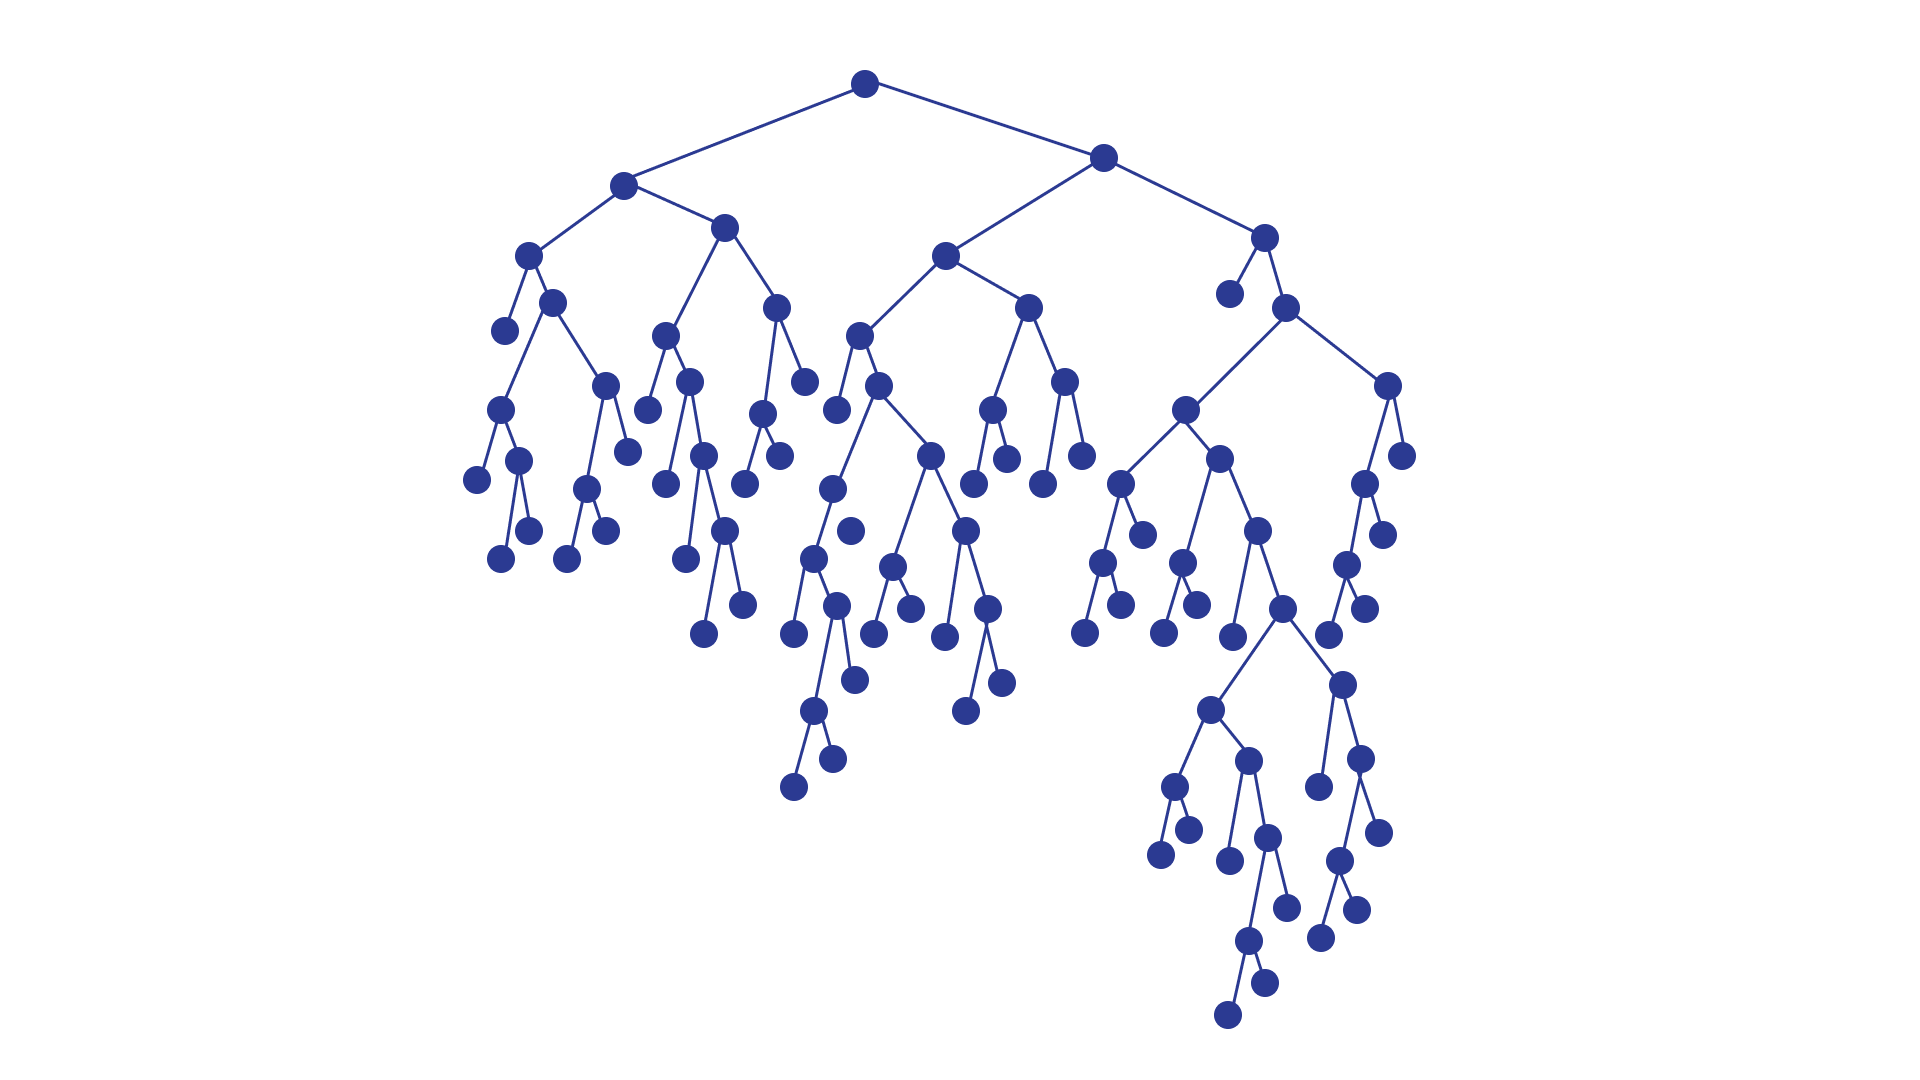



Все вершины дерева делятся на **листовые** и **внутренние**. Работа дерева сводится к последовательному перемещению по этим вершинам вдоль ребер по следующему принципу.

На вход дерева подается некоторый объект, представленный вектором своего признакового описания. В каждой внутренней вершине для исходного объекта вычисляется значение некоторого выражения, которое может принимать одно из двух значений - True или False. В зависимости от этого значения мы идем в левую или правую ветвь данного дерева, пока наконец не придем к некоторой листовой вершине. Каждая  листовая вершина содержит в себе некоторый ответ, который мы и принимаем в качестве результата классификации исходного объекта. Обобщение на задачу регрессии рассмотрим немного позже.

___________
**Определение.** Предикатом $β$ будем называть некоторое выражение, которое может быть верным или ложным для некоторого объекта $x$.

**Замечание:** вообще понятие предиката несколько более широкое, чем приведённое в данной лекции. Мы же под предикатами будем понимать функции вида
$$β(\vec{x}) = [ (-1)^j \cdot x_i > a ]$$

То есть просто ответ на вопрос: правда ли, что i-я координата вектора признакового описания больше (меньше) некотрого наперёд заданного числа a?
___________

Формально этот алгоритм можно описать следующим образом.

Пусть $v_0$ - начальная вершина решающего дерева, $v$ - текущая вершина. Тогда алгоритм принятия решения для решающего дерева выглядит следующим образом:
1. $v=v_0$
2. Пока вершина $v$ - внутренняя:
  * если значение предиката (функции) $\beta_v$ в вершине $v$ равно 1, то переходим к рассмотрению вершины, которая находится справа снизу от текущей;
  * в противном случае - рассматриваем левую нижнюю вершину.
3. Когда добрались до листовой вершины - возвращаем класс $c_v$, соответствующий данной вершине.

Обратите внимание, в отличие от линейных методов в нашем случае нет необходимости рассматривать изначально задачу бинарной классификации, мы можем сразу говорить про общий случай задачи многоклассовой классификации.




所有树节点都分为**叶**和**内部**。根据以下原理，树的工作简化为沿着这些顶点沿边的顺序移动。

由其特征描述向量表示的对象被输入到树的输入。在原始对象的每个内部节点处，都会计算某些表达式的值，该表达式可以取两个值之一 - True 或 False。根据这个值，我们转到树的左边或右边的分支，直到最终到达某个叶节点。每个叶节点包含一些答案，我们将其接受为原始对象分类的结果。稍后我们将考虑对回归问题的推广。

___________
**定义**谓词 $β$ 是一个对于某个对象 $x$ 来说可以为真或为假的表达式。

**注意：**一般来说，谓词的概念比本讲座中给出的概念要广泛一些。通过谓词，我们将理解形式函数
$$β(\vec{x}) = [ (-1)^j \cdot x_i > a ]$$

也就是说，简单地回答这个问题：特征描述向量的第 i 个坐标是否大于（小于）某个预设数字 a？
___________

正式地，该算法可以描述如下。

令$v_0$为决策树的初始顶点，$v$为当前顶点。那么决策树的决策算法如下所示：
1. $v=v_0$
2. 当顶点 $v$ 是内部时：
* 如果顶点 $v$ 处的谓词（函数）$\beta_v$ 的值等于 1，那么我们继续考虑位于当前顶点右下方的顶点；
* 否则，我们考虑左下顶点。
3. 当我们到达一个叶节点时，我们返回与该节点对应的$c_v$类。

请注意，与线性方法不同，在我们的例子中，不需要首先考虑二元分类的问题；我们可以立即讨论多类分类问题的一般情况。

# Геометрическая интерпретация

Рассмотрим двумерный случай, то есть когда признаков всего 2. В этом случае работа алгоритма решающего дерева прозрачна: решающее дерево выделяет области на плоскости, характеризуемые принадлежностью к тому или иному классу.

几何解释

让我们考虑二维的情况，即只有 2 个特征的情况。在这种情况下，决策树算法的操作是透明的：决策树识别平面上属于某一类或另一类的区域。

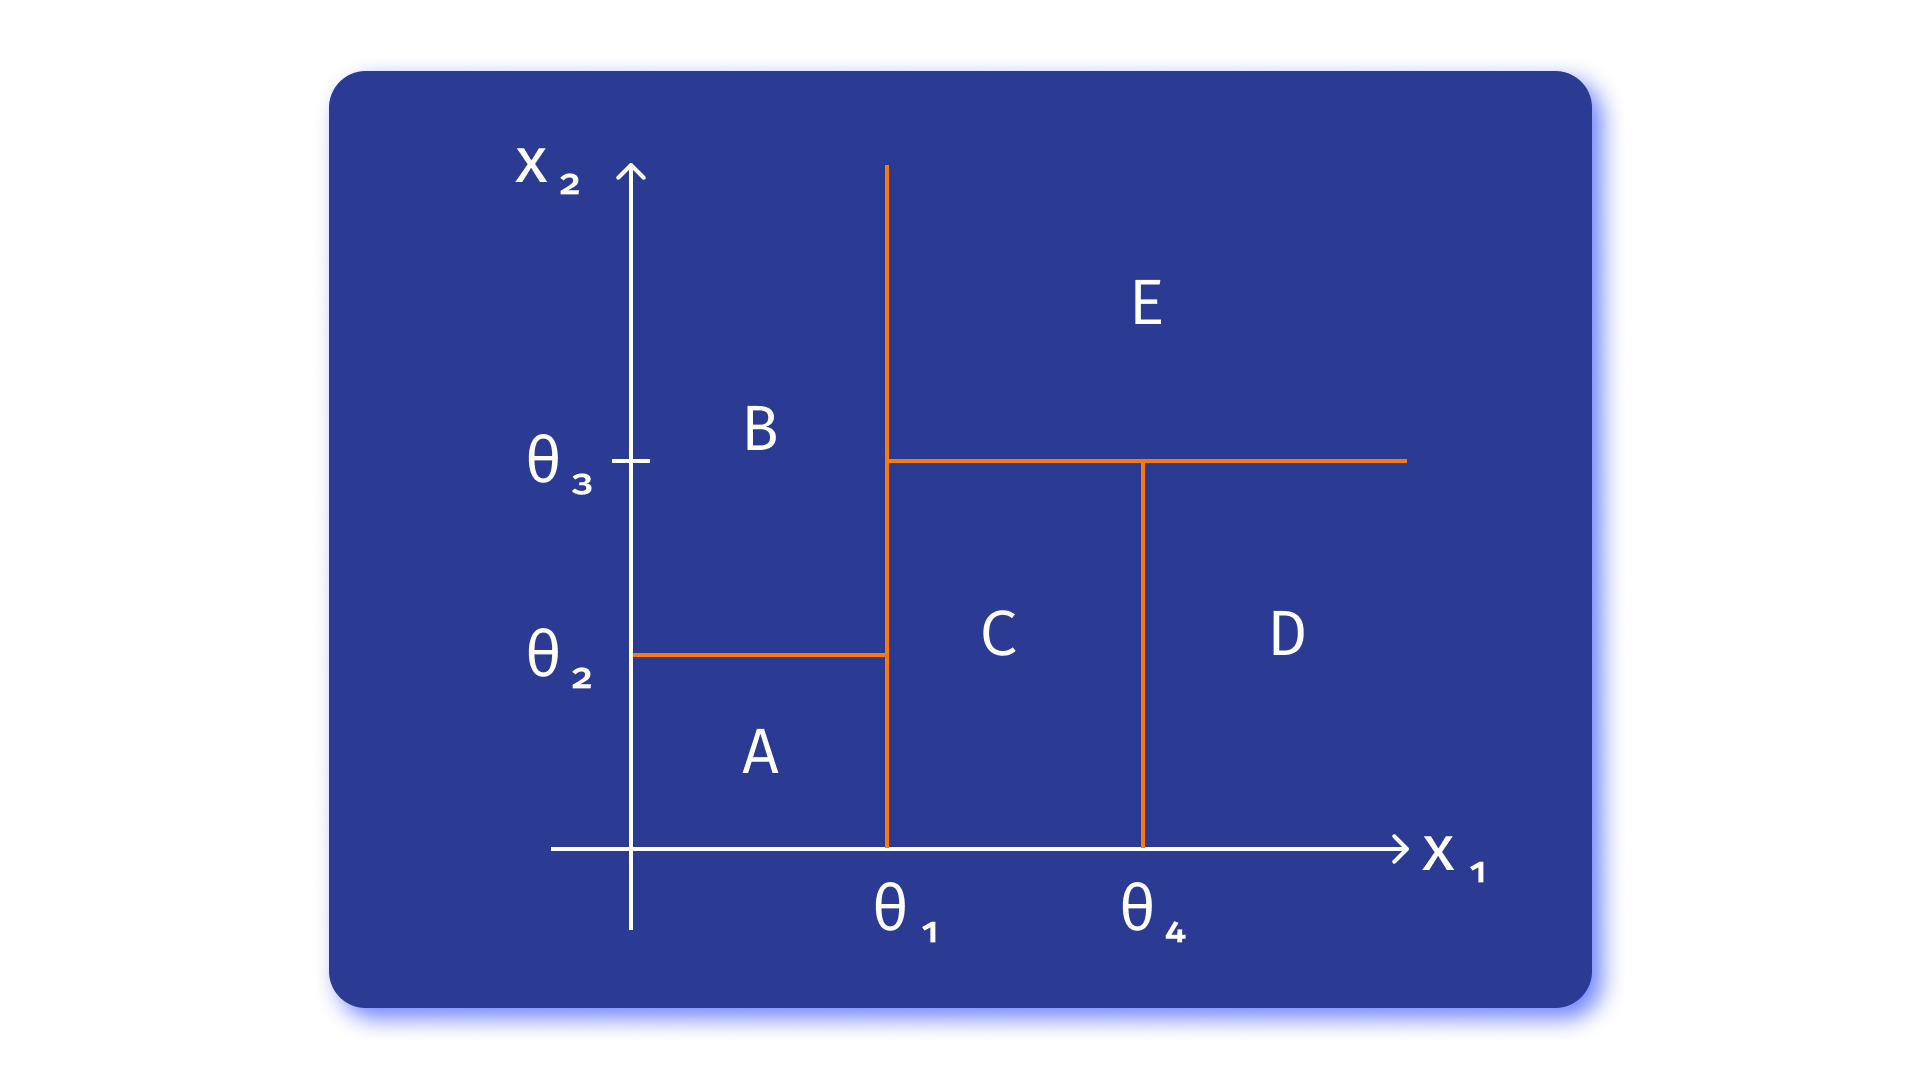



Действительно, для данной картинки структура решающего дерева будет выглядеть так:

事实上，对于这张图片，决策树的结构将是这样的：

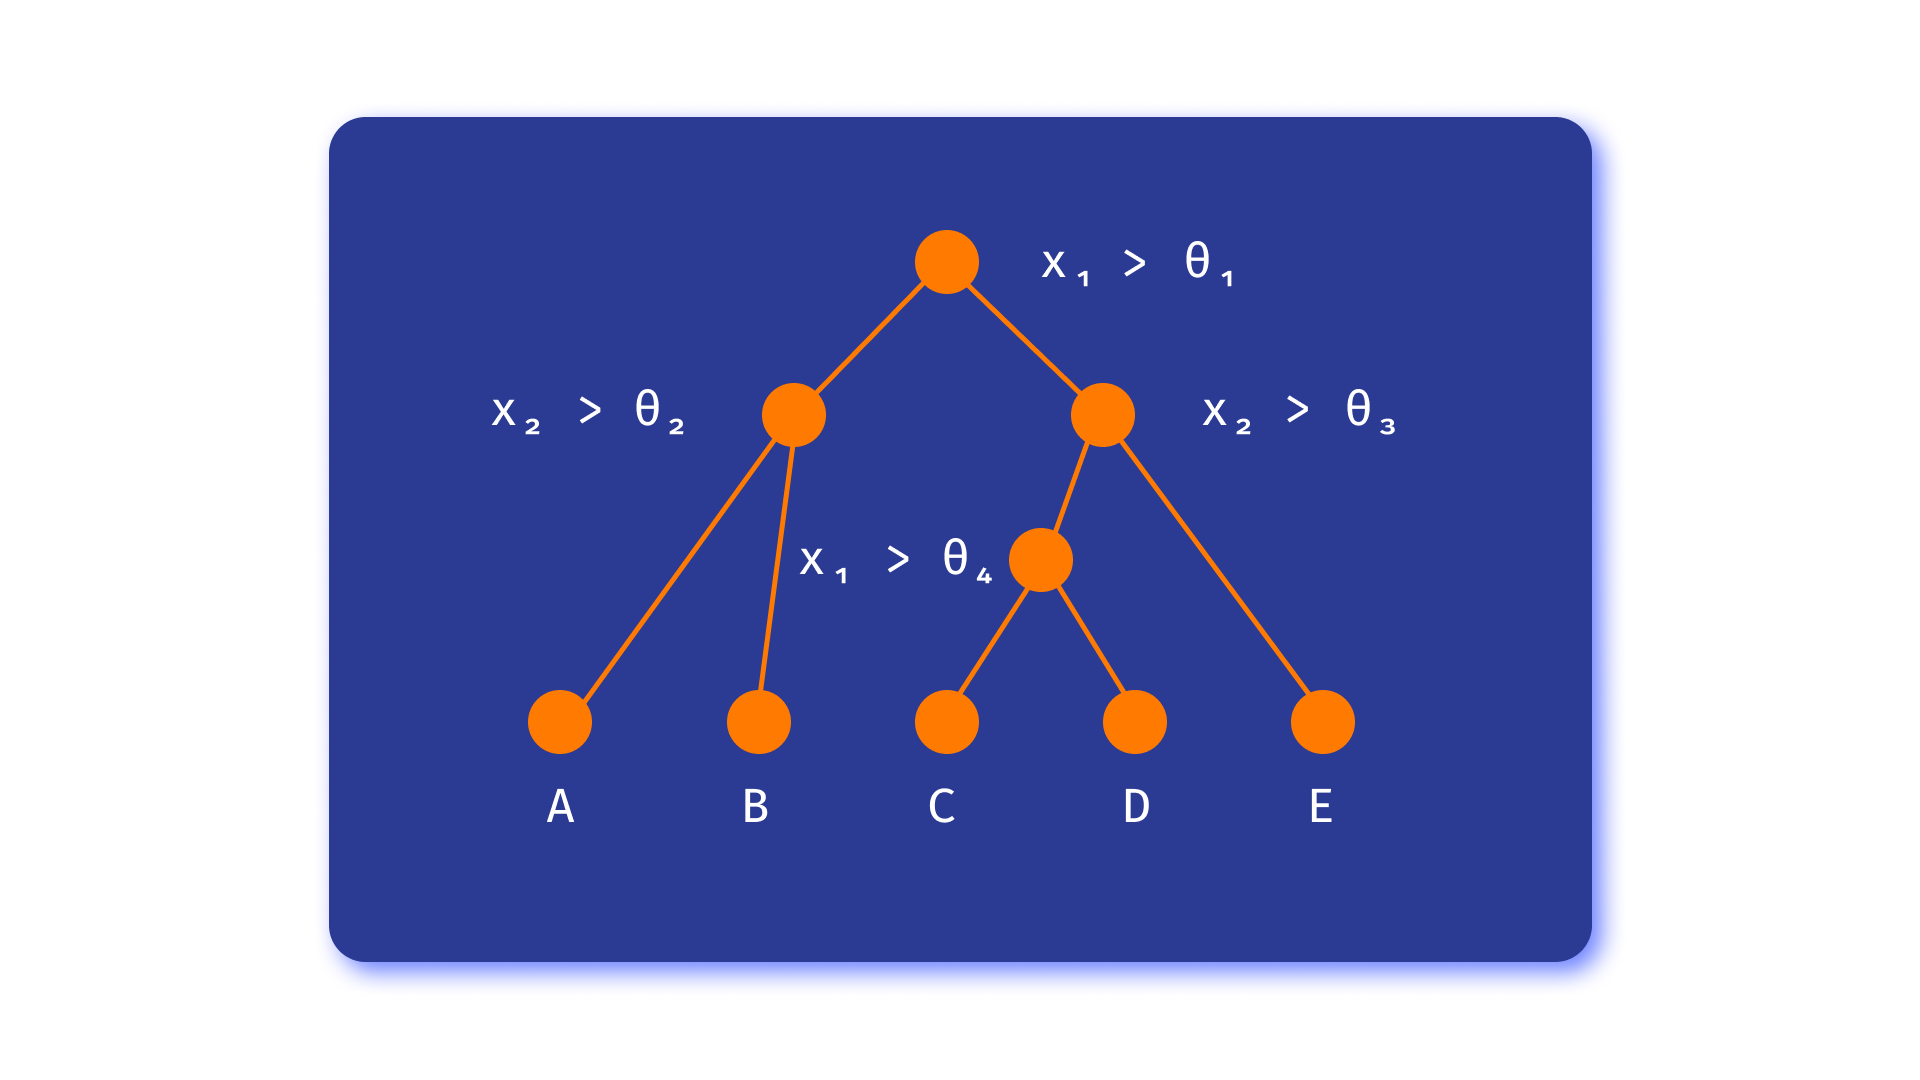

# Построение решающих деревьев

Мы разобрались, как работает алгоритм решающего дерева, когда дерево уже построено. Но пока не совсем ясно как, имея на руках размеченную выборку, построить наилучшее решающее дерево для ее разметки. Давайте разберемся с этим вопросом, рассмотрев в качестве примера один из многих алгоритмов построения решающих деревьев.

В целом построение решающих деревьев сводится к следующему:

а) Выбор количества внутренних и листовых вершин.

б) Выбор разметки листовых вершин.

в) Выбор последовательности предикатов во внутренних вершинах.

Обычно построение дерева происходит при помощи последовательного разбиения исходной выборки на две части таким образом, чтобы качество разбиения каждой подвыборки было наилучшим (что это значит, мы уточним позже). Такое последовательное разбиение задает все 3 пункта построения решающего дерева.

Пока что звучит очень абстрактно. Рассмотрим конкретный пример такого алгоритма.

决策树的构建

一旦树被构建出来，我们就弄清楚了决策树算法是如何工作的。但目前还不完全清楚，如何在手头有标记样本的情况下，为其标记构建最佳决策树。让我们以众多决策树算法之一作为示例来看一下这个问题。

一般来说，决策树的构建归结为以下内容：

a) 选择内部顶点和叶顶点的数量。

b) 选择叶节点的布局。

c) 在内部节点处选择谓词序列。

通常，树是通过将原始样本连续分割成两部分来构建的，使得每个子样本的分割质量都是最好的（我们稍后会阐明这意味着什么）。这种顺序分区定义了构建决策树的所有 3 个点。

现在听起来这很抽象。让我们考虑一下这种算法的一个具体例子。

# LearnID3

Этот алгоритм представляет собой иллюстрацию базовой идеи построения решающего дерева. На сегодняшний день разработаны и более интересные его модификации. Но мы рассмотрим именно базовый вариант.

Алгоритм сводится к следующей последовательности действий:

> 1. На вход мы получаем выборку пар объектов, взятых из пространства признаковых описаний X и ответов из множества классов: U = {$(x,y) | x \in X, y \in \{1 ... N\}$} (N здесь - число возможных классов).
> 2. Если все объекты в выборке лежат в одном и том же классе c:
>> Вернуть листовую вершину класса c.
>3. Иначе:
>4. Найдем предикат (то есть выражение, принимающее значение True или False) β, с помощью которого наилучшим образом разобьем исходную выборку на 2 части.

Наилучшее разбиение будем строить на основании некоторого правила, которое назовем критерием информативности. Это некоторая функция $H(β, U)$, которая по заданной подвыборке скажет, насколько хорошим было разбиение.
>5. Разбить выборку на 2 части по предикату β: $U_0 = \{x \in U: β(x) = False\}$ и $U_1 = \{x \in U: β(x) = True\}$
>6. Если одна из этих подвыборок пуста, то
>> Вернуть листовую вершину **мажоритарного** класса в U.
>7. Создать новую внутреннюю вершину с предикатом β.
>8. Построить левое поддерево и правое поддерево, вызовом LearnID3($U_0$) и LearnID3($U_1$).



学习ID3

这个算法说明了决策树构建的基本思想。如今，更多有趣的修改已经面世。但我们会考虑基本选择。

该算法可归结为以下一系列操作：

> 1. 在输入处，我们接收从特征描述空间 X 中获取的对象对样本和来自一组类别的响应：U = {$(x,y) | x \in X, y \in \{1 ... N\}$} （此处 N 是可能的类别的数量）。
> 2. 如果样本中的所有对象都属于同一类 c：
>> 返回类 c 的叶节点。
>3.否则：
>4.让我们找到一个谓词（即取值 True 或 False 的表达式）β，借助它我们可以将原始样本最好地分成两部分。

我们将根据一定的规则构建最佳划分，我们称之为信息含量准则。这是某个函数 $H(β, U)$，给定一个子样本，它将告诉我们分割的效果有多好。
>5。根据谓词 β 将样本分为两部分：$U_0 = \{x \in U: β(x) = False\}$ 和 $U_1 = \{x \in U: β(x) = True\}$

>6.如果其中一个子样本为空，则
>> 将**多数**类的叶节点返回给 U。

>7.创建一个新的具有谓词β​​的内部节点。

>8.通过调用 LearnID3($U_0$) 和 LearnID3($U_1$) 来构建左子树和右子树。

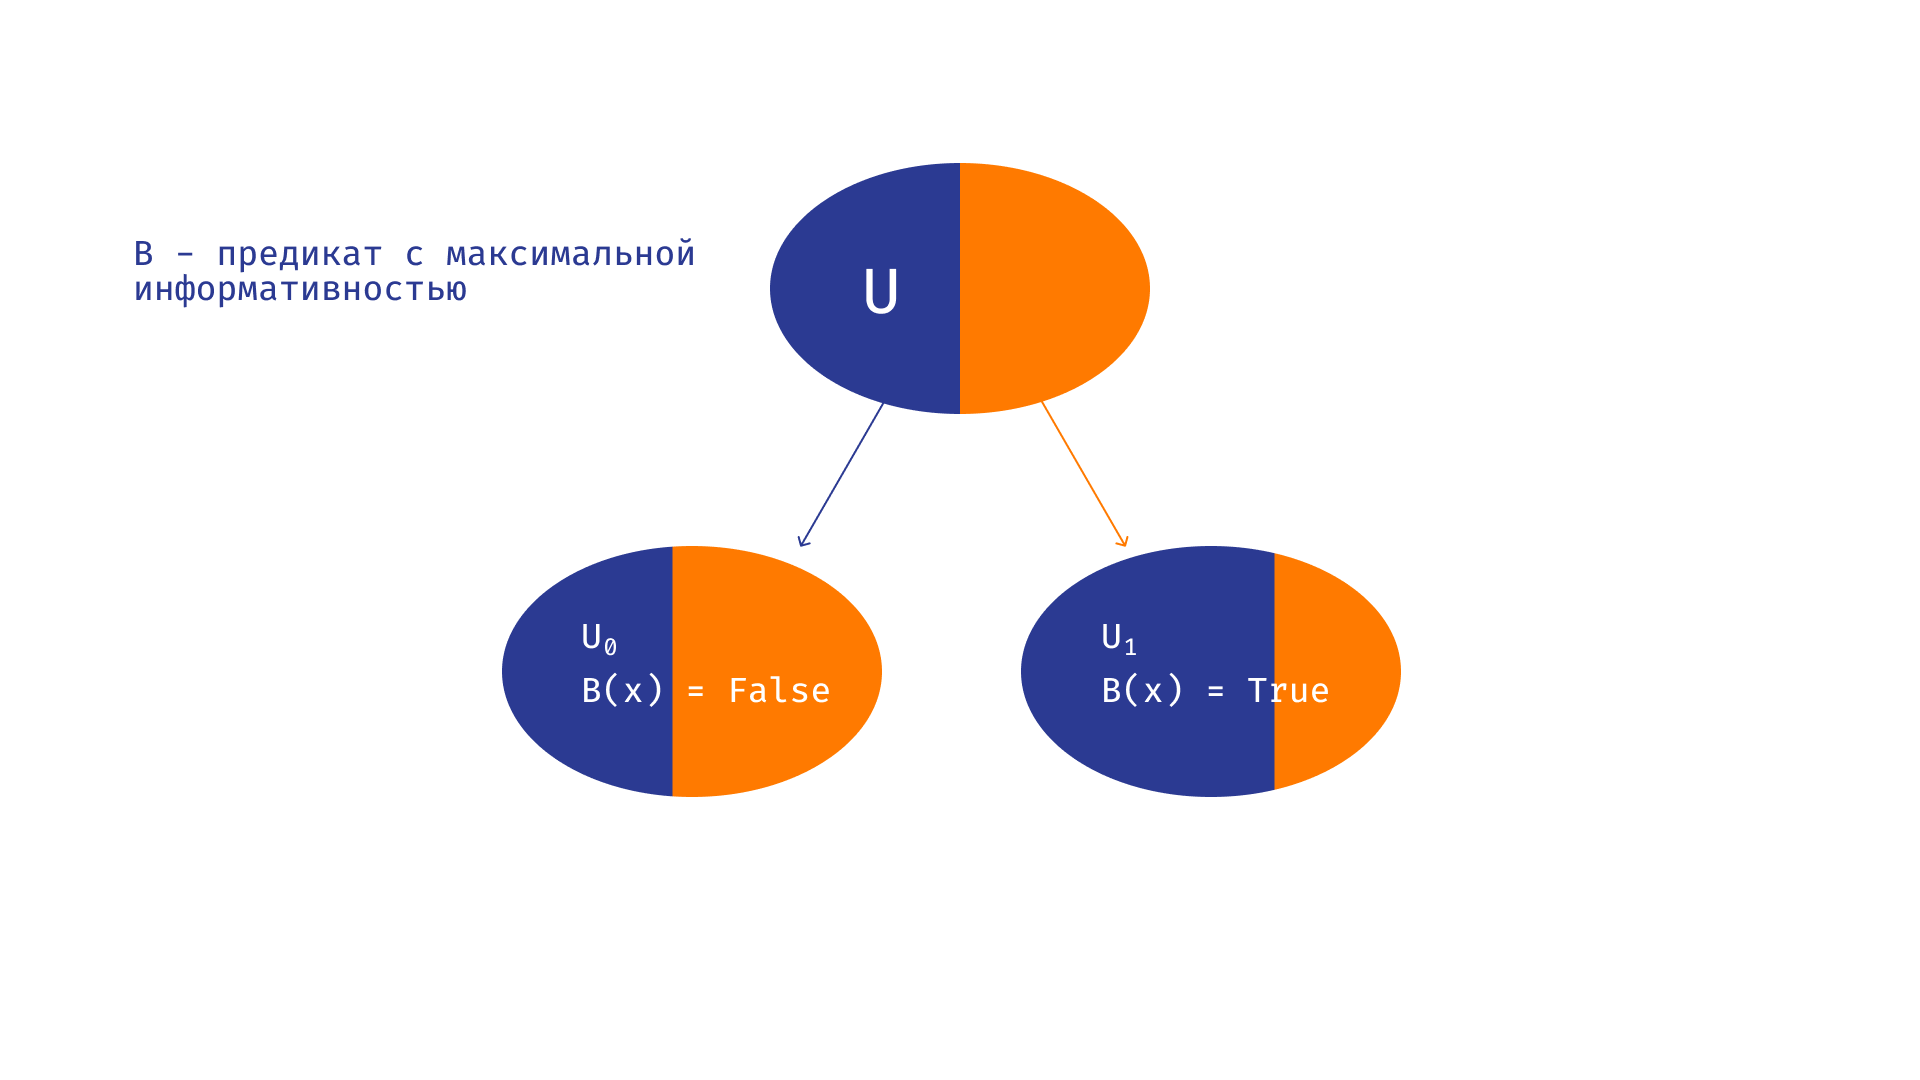

# Критерии информативности

Как уже было сказано, для построения дерева решений необходимо определить некоторый критерий информативности, который оценивает качество распределения целевой переменной среди объектов множества предикатов. То есть чем больше значение критерия информативности, тем более точно подобран предикат.

В качестве примера можно рассмотреть критерий Джини:
$$I(β, X)=|\{(x_i, x_j): y_i=y_j, β(x_i)=β(x_j)\}|$$

Вторым примером служит похожий D-критерий В. И. Донского:
$$I(β, X)=|\{(x_i, x_j): y_i \neq y_j, β(x_i) \neq β(x_j)\}|$$

Критерий Джини считает, сколько из попавших в одну и ту же ветвь согласно разделению по предикату β объектов действительно должны были оказаться в одной ветви.

Критерий Донского же наоборот считает сколько из объектов, попавших в разные ветви, принадлежат разным классам.

Эти критерии похожие, но не эквивалентные.

# Замечание
___________________
Нужно отметить, что классическим критерием в процедуре LearnID3 служит третий критерий - энтропийный. Он оценивает информационные свойства разбиения. Мы не рассматриваем его, поскольку для этого нам пришлось бы погрузиться в изучение теории информации, предварительно проговорив основные положения теории вероятностей. Однако представленые критерии дают представление о возможном способе отбора предикатов, который мы считаем вполне достаточным для правильной и качественной работы с данными моделями.
___________________

# Критерии останова

Если продолжить процедуру LearnID3 до конца, мы получим очень сильно переобученную структуру. Поэтому рассмотрим некоторые критерии досрочной остановки этой процедуры.

В качестве примеров критерия останова можно рассмотреть следующие правила:

1. Ограничение на размеры дерева (максимальная глубина, количество листовых вершин, общее количество вершин).
2. Ограничение на количество объектов в листовых вершинах.
3. Остановка алгоритма в случае, если все объекты относятся к одному классу.

信息内容标准

如前所述，要构建决策树，必须定义一些信息内容标准来评估目标变量在谓词集对象之间的分布质量。也就是说，信息含量标准的值越高，谓词的选择就越准确。

作为一个例子，我们可以考虑基尼标准：
$$I(β, X)=|\{(x_i, x_j): y_i=y_j, β(x_i)=β(x_j)\}|$$

第二个例子是V. I. Donskoy的类似D标准：
$$I(β, X)=|\{(x_i, x_j): y_i \neq y_j, β(x_i) \neq β(x_j)\}|$$

基尼标准计算根据谓词 β 划分而最终落入同一分支的对象中，有多少个对象实际上应该最终落入同一分支。

相反，顿斯科伊标准计算的是属于不同分支的对象中有多少属于不同的类别。

这些标准相似但并不等同。

笔记
___________________
需要注意的是，LearnID3程序中的经典标准是第三个标准——熵标准。它评估分区的信息属性。我们不考虑它，因为要这样做我们必须深入研究信息论，首先讨论概率论的基本原理。然而，所提出的标准给出了选择谓词的可能方法的想法，我们认为这对于这些模型的正确和高质量工作来说已经足够了。
___________________

停止标准

如果我们将 LearnID3 过程一直延续到最后，我们将得到一个过度拟合的结构。因此，让我们考虑一些提前终止该程序的标准。

以下规则可被视为停止标准的示例：

1. 树的大小限制（最大深度、叶节点数、节点总数）。
2. 叶节点中对象数量的限制。
3. 如果所有对象都属于同一类，则停止算法。

# Обработка пропусков решающими деревьями

Решающие деревья обладают замечательным свойством:
они могут работать с данными, в которых есть пропуски. Идея такого свойства очень простая.

Пусть нам встретился объект с пропуском в i-й координате, то есть мы не знаем, чему равно значение $x_i$.

Пусть в листовой вершине V нам необходимо вычислить значение предиката $β_v$ вида $\beta_v = [x_i > a]$ (или $[x_i < a]$), где a - некоторое число. Значение предиката не может быть вычислено, то есть мы не знаем, следует ли нам отправить объект x в правую ветвь дерева или же в левую.

Тогда примем решение следующим образом:

На этапе обучения дерева в каждой вершине будем считать вероятность отправить случайно выбранный объект влево или же вправо (то есть посчитаем, сколько объектов из обучающей выборки мы отправили влево, а сколько вправо, а затем поделим то и то на количество объектов в выборке).

На этапе тестирования модели мы определяем, в какую ветку наш объект попадет с наибольшей вероятностью. Согласно оценке этой вероятности, сформированной на этапе обучения, и принимаем соответствующее решение.

Работа алгоритма продолжается несмотря на невозможность вычисления значения некоторого предиката.


使用决策树处理差距

决策树有一个显著的特性：
他们可以处理存在空白的数据。这个属性背后的想法非常简单。

假设我们遇到一个在第 i 个坐标上有间隙的物体，也就是说，我们不知道$x_i$的值是多少。

假设在叶节点 V 处，我们需要计算形式为 $\beta_v = [x_i > a]$（或 $[x_i < a]$）的谓词 $β_v$ 的值，其中 a 是某个数字。谓词的值无法计算，也就是说，我们不知道应该将对象 x 发送到树的右边分支还是左边。

然后我们将做出如下决定：

在树的训练阶段，在每个节点上，我们会计算将随机选择的对象发送到左边或右边的概率（也就是说，我们会计算从训练样本中将多少个对象发送到左边，多少个对象发送到右边，然后将两者都除以样本中的对象数量）。

在模型测试阶段，我们确定我们的对象最有可能落入哪个分支。根据在训练阶段形成的概率评估，我们做出适当的决定。

尽管无法计算某些谓词的值，算法仍继续运行。

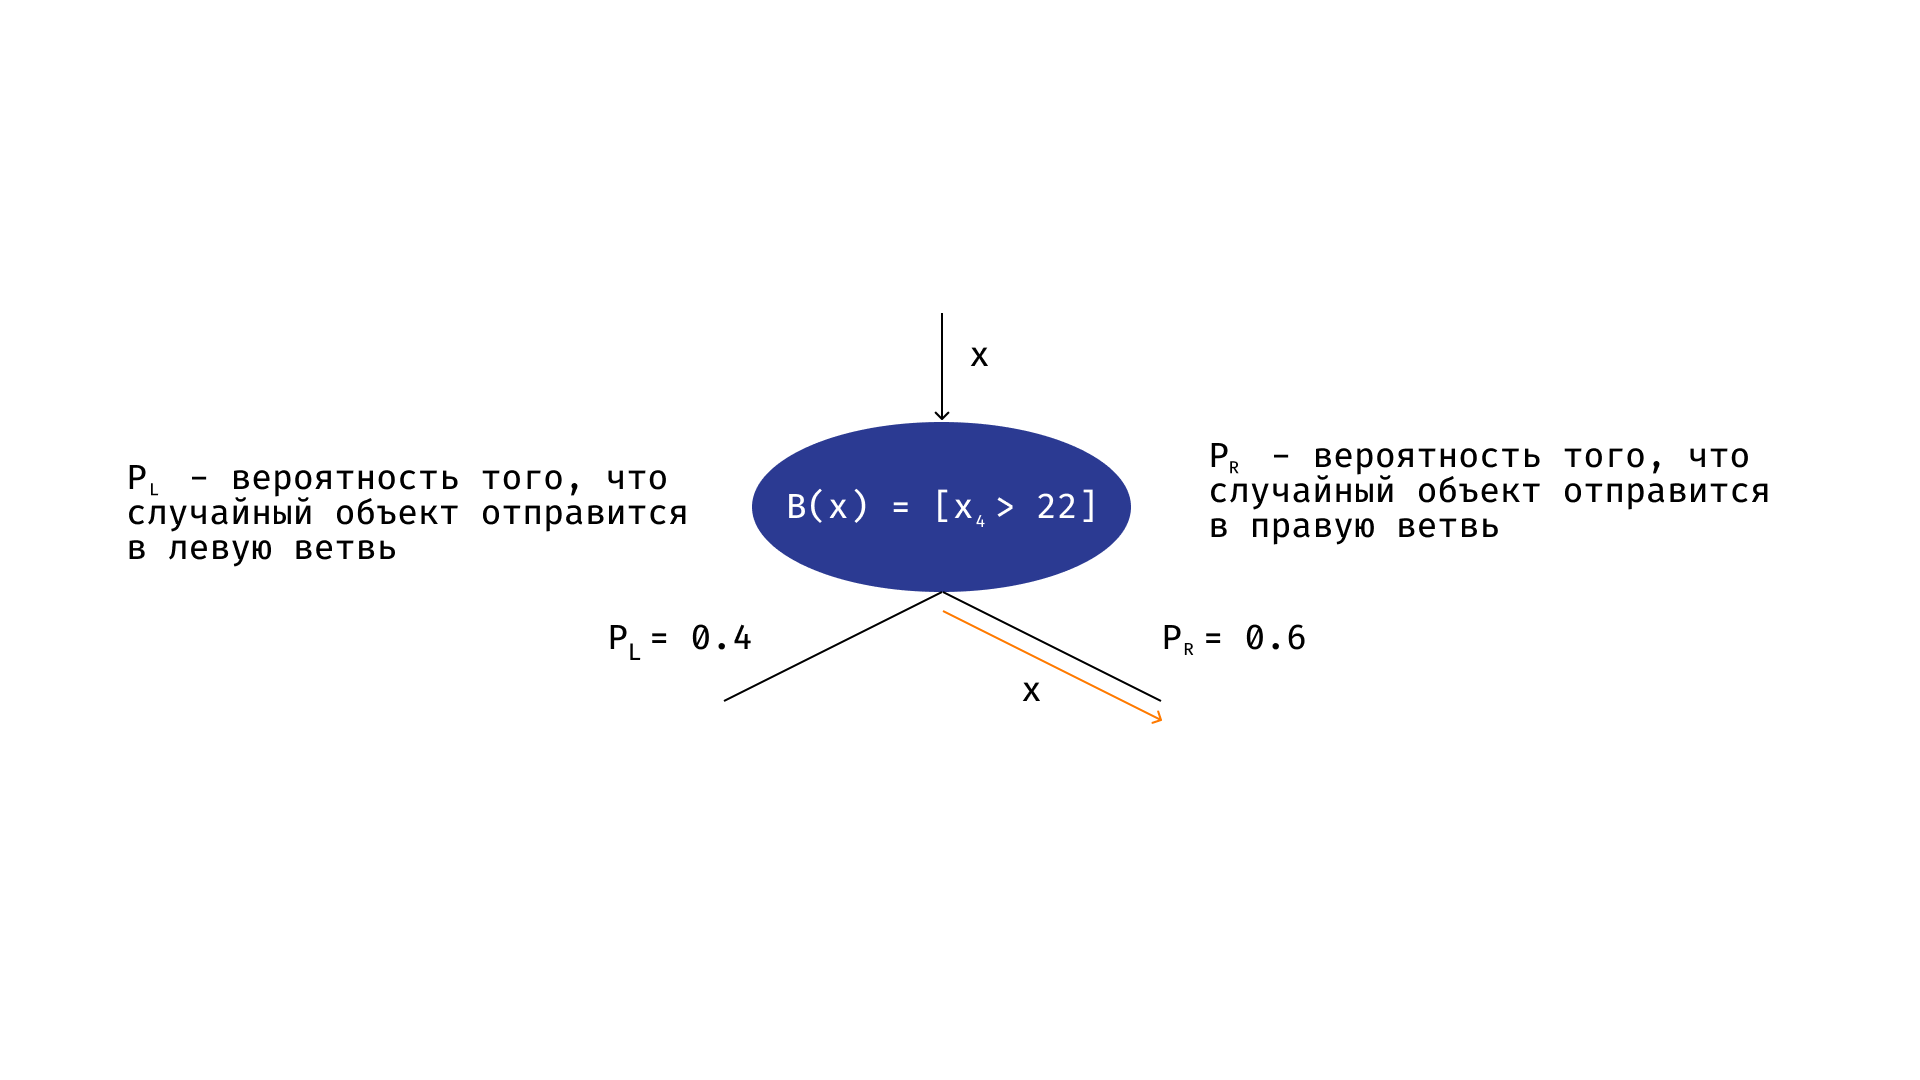

# Обобщение на задачу регрессии

Обобщение на задачу регрессии строится при помощи следующего трюка: вместо метки класса в листовую вершину поместим некоторое значение предсказания. В дальнейшем алгоритм работы решающего дерева очень похож на случай классификации: мы распределяем объекты по листовым вершинам, а также в процессе обучения считаем среднее значение меток для объектов, попавших в каждую из листовых вершин. Предсказание на этапе теста будет равно именно этому среднему значению.

В случае с регрессией и критерии ветвления  используются другие. Изученные ранее критерии не подходят, ведь теперь понятие класса объекта вообще не определено. В связи с этим определяются другие критерии ветвления, например критерий ветвления, основанный на минимизации дисперсии меток объектов, абсолютное отклонение от медианы и т.п.

推广到回归问题

使用以下技巧可以构建回归问题的泛化：我们将一些预测值放在叶节点中，而不是类标签中。将来，决策树的算法与分类的情况非常相似：我们在叶节点之间分配对象，并且在训练过程中计算落入每个叶节点的对象的标签的平均值。测试阶段的预测将正是这个平均值。

在回归的情况下，使用其他分支标准。之前研究的标准并不适用，因为现在对象类的概念根本没有定义。在这方面，定义了其他分支标准，例如基于最小化对象标签的方差、与中位数的绝对偏差等的分支标准。

## Связь критериев ветвления с классическими функциями потерь*

_____________________________
Критерии ветвления для деревьев имеют смысл, аналогичный loss-функции для линейных алгоритмов.

Например, пусть задача нашего дерева - минимизировать среднеквадратичную ошибку в каждом листе. То есть если $Y$ - набор меток объектов, относящихся к некоторому листу, $c$ - предсказание данного листа. Функцию потерь тогда мы могли бы определить следующим образом:
$$L(y_i, c) = (y_i - c)^2$$
Тогда оценка loss на всём наборе в данном листе:
$$Q(X, Y, c) = \frac{1}{N}\sum\limits_{i=1}^N(y_i - c)^2 → \min\limits_c$$
Оптимальным $c$ в данном случае будет, как не трудно убедиться, $c = \frac{\sum\limits_{i=1}^Ny_i}{N}$
Тогда:
$$Q^*(X, Y) = \frac{1}{N}\sum\limits_{i=1}^N(y_i - \bar{y})^2$$
Где $\bar{y}$ - это среднее значение $y_i$. То есть, $Q^*$ представляет из себя оценку дисперсии выборки в каждом листе, которую мы хотим минимизировать. То есть минимизация $Q^*$ и есть наш критерий ветвления.

Аналогичным образом можно прийти, например, к тому, что критерий минимизации абсолютного отклонения меток в листе от медианного значения соответствует другой популярной функции потерь:
$$L(y_i, c) = |y_i - c|$$

分支标准与经典损失函数的关系*

_____________________________
树的分支标准具有与线性算法的损失函数类似的含义。

例如，假设我们树的目标是最小化每个叶子的均方误差。也就是说，如果 $Y$ 是属于某个叶子的对象的标签集合，则 $c$ 是该叶子的预测。然后我们可以定义损失函数如下：
$$L(y_i, c) = (y_i - c)^2$$
那么本表中整个集合的损失估计为：
$$Q(X, Y, c) = \frac{1}{N}\sum\limits_{i=1}^N(y_i - c)^2 → \min\limits_c$$
在这种情况下，最佳 $c$ 将是，很容易看出，$c = \frac{\sum\limits_{i=1}^Ny_i}{N}$
然后：
$$Q^*(X, Y) = \frac{1}{N}\sum\limits_{i=1}^N(y_i - \bar{y})^2$$
其中 $\bar{y}$ 是 $y_i$ 的平均值。也就是说，$Q^*$ 表示我们想要最小化的每个叶子中的样本方差的估计值。也就是说，最小化 $Q^*$ 是我们的分支标准。

类似地，我们可以得出这样的结论：例如，最小化一张纸上的标签与中值的绝对偏差的标准对应于另一个流行的损失函数：
$$L(y_i，c) = |y_i - c|$$

# Переобучение и недообучение
______________________________________________
Сделаем небольшое отступление и обсудим две очень важные проблемы обучения всех моделей ML.

Эти общие проблемы называются **переобучением** и **недообучением**. Их названия достаточно полно описывают их суть, но мы подробно разберёмся в причинах их возникновения.


过度拟合和欠拟合
______________________________________________
让我们稍微离题一下，讨论一下训练所有 ML 模型时的两个非常重要的问题。

这些常见的问题被称为**过度拟合**和**欠拟合**。它们的名字已经十分充分地描述了它们的本质，但我们将详细探讨它们出现的原因。


## Недообучение
Недообучение - это случай, когда модель по тем или иным причинам не смогла обобщить закономерности в данных и выучить необходимые зависимости.

Общих причин у проблемы недообучения может быть две:
- Модели просто не хватило времени на обучение. Под временем здесь понимается, скажем, количество шагов градиентного спуска. То же может относиться к неправильно выставленным гиперпараметрам, например, learning rate (см. Лекцию 3)
- Модель технически не может выучить слишком сложные для неё зависимости. Иначе говоря, модели не хватает **ёмкости**. Приведем пример такой ситуации.



训练不足

欠拟合是指模型由于某种原因无法概括数据中的模式并学习必要的依赖关系的情况。

训练不足的问题可能有两个常见原因：
- 模型根本没有足够的时间学习。这里，时间被理解为梯度下降的步数。这同样适用于错误设置的超参数，例如学习率（参见第 3 讲）
- 从技术上讲，该模型无法学习对其而言过于复杂的依赖关系。换句话说，该模型缺乏**容量**。让我们举一个这种情况的例子。

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

x = np.linspace(-1, 1, 100)
y = np.polyval([2, 1, 0.3, -1], x) + np.random.randn(x.shape[0]) * 0.2

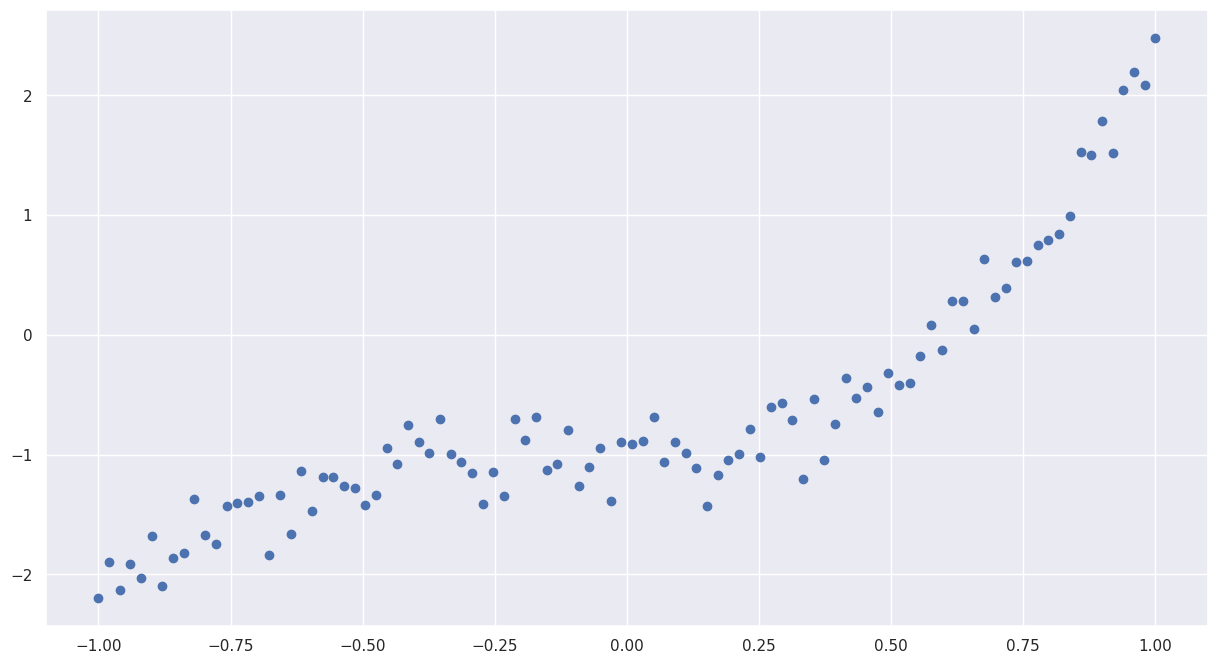

In [ ]:
plt.figure(figsize=(15,8))
plt.scatter(x,y)

В данном случае требуется смоделировать поведение полинома 3 степени. Что получится, если мы попробуем построить линейную регрессию?

在这种情况下，需要对三次多项式的行为进行建模。如果我们尝试建立线性回归会发生什么？

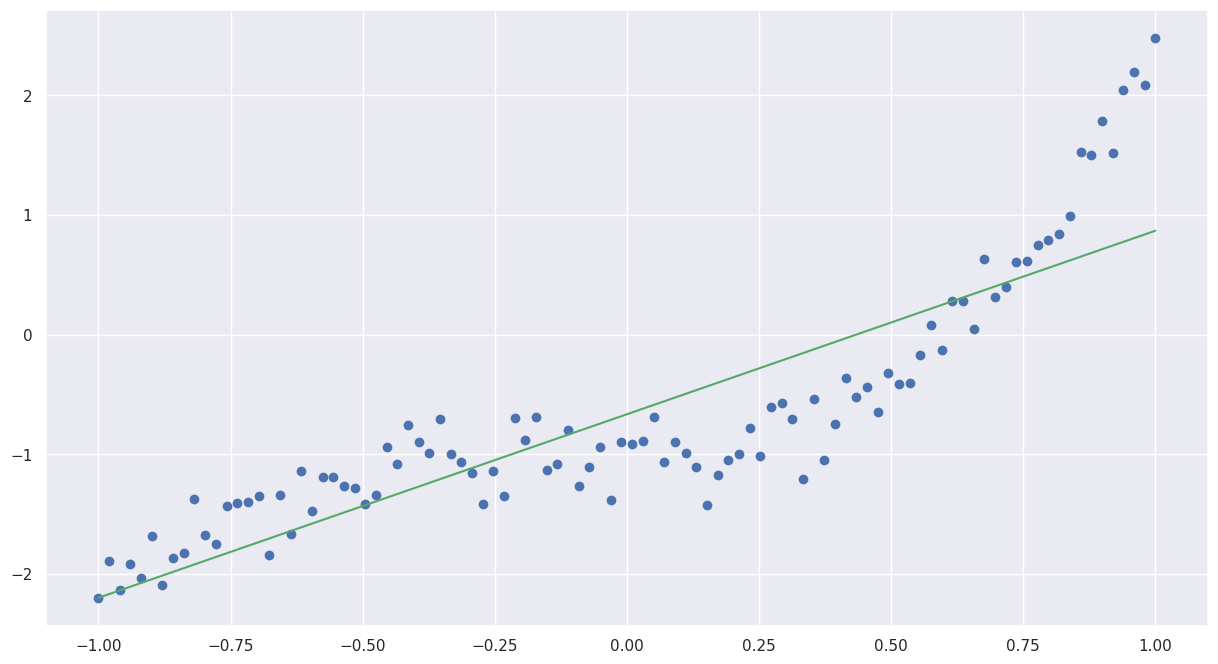

In [ ]:
from sklearn.linear_model import LinearRegression

LR = LinearRegression().fit(x.reshape(-1, 1), y)
preds = LR.predict(x.reshape(-1, 1))

plt.figure(figsize=(15,8))
plt.scatter(x, y)
plt.plot(x, preds, c="g")

Очевидно, что логистическая регрессия с этой задачей не справляется. Всё дело в том, что этой модели банально не хватает параметров для того, чтобы смоделировать слишком сложную зависимость. Это один из возможных примеров ситуации **недообучения**.

Решение проблемы недообучения обычно довольно простое. Достаточно выбрать более сложные модели с большим числом параметров, либо увеличить количество итераций обучения.

Если в приведенном примере мы увеличим число параметров модели, заменив линейную регрессию полиномиальной регрессией третьей степени, мы без труда решим поставленную задачу с достаточно высокой точностью.

显然逻辑回归无法应对这项任务。关键在于，该模型根本缺乏模拟过于复杂关系的参数。这是**训练不足**情况的一个可能例子。

欠拟合问题的解决方案通常非常简单。选择具有更多参数的更复杂模型，或者增加训练迭代次数就足够了。

如果在给定的例子中，我们增加模型参数的数量，用三次多项式回归代替线性回归，我们将轻松地以足够高的精度解决问题。

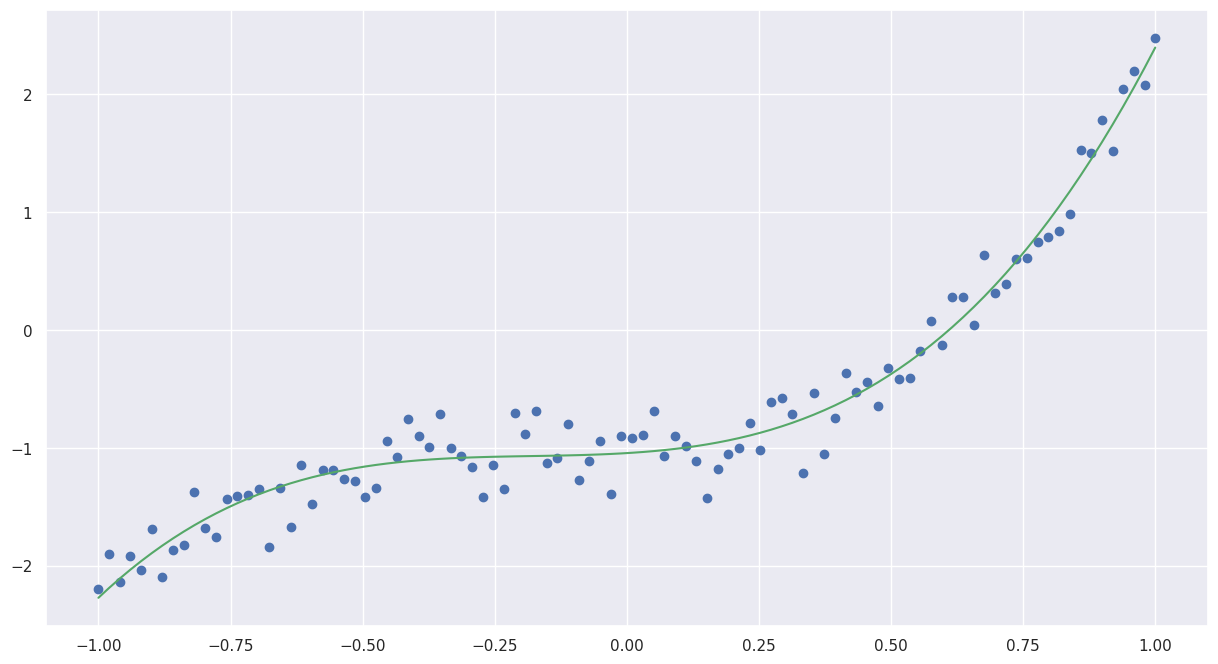

In [ ]:
coef = np.polyfit(x, y, 3)
preds = np.polyval(coef, x)


plt.figure(figsize=(15,8))
plt.scatter(x, y)
plt.plot(x, preds, c="g")

## Переобучение

Проблема переобучения более сложная и комплексная, чем проблема недообучения.

Если недообучение связано с недостаточной сложностью выбранной модели, то переобучение следует из **избыточной сложности**. Вопреки нашим ожиданиям, слишком сложная модель также неспособна выучить нужные зависимости в данных. Вернее, она с высокой вероятностью выучит зависимости в данных, которые там появились по чистой случайности и не являются естественными для нашей задачи.

Другой распространённой причиной проблемы переобучения является **недостаток данных**. На самом деле, недостаток данных в некоторых случаях может быть скомпенсиррован уменьшением сложности модели. Наше желание усложнить модель всегда приводит нас к необходимости увеличить и набор данных, которые мы используем для обучения.

Приведём несколько примеров:

### Пример 1

Представьте себе, что Вы обучаете иностранца из очень далёкой страны играть в "монетку". Вы хотите, чтобы он понял основную суть игры: у монетки есть 2 состояния ("орёл" и "решка"), которые выпадают случайно с равной (или почти равной) вероятностью.

Вы начинаете демонстрировать иностранцу серию экспериментов, подбрасывая монетку и объявляя ему результат.

Допустим, вы бросили монетку 3 раза и остановились на этом. Житейский опыт подсказывает, что результат трёхкратного выпадения орла в этом случае совершенно реален. Предположим, так и вышло и иностранец услышал, что трижды выпал орёл. Что произойдёт, если теперь Вы спросите у него, как он понимает правила этой игры?

Иностранец, конечно, скажет Вам, что эта игра очень глупая и весь её смысл сводится к тому, чтобы наблюдать выпадения орла.
Это заблуждение иностранца - следствие его переобучения из-за недостатка данных.

### Пример 2

Когда мы обсуждали недообучение, мы пытались смоделировать многочлен третьей степени слишком простой моделью, то есть линейной регрессией. Она плохо справилась с задачей. Здравый смысл подсказывает нам, что и полином второйй степени вряд ли справится с этой задачей хорошо, ведь исходные данные смоделированны при помощи поолиномиальной зависимости третьей степени. Вот почему полином третьей степени уже достаточно хорошо смоделировал эту выборку. А что если взять полином 4 степени в качестве модели? А 5? Может быть, 30 степени? Ведь каждый из них может моделировать и зависимости меньших порядков, то есть в теории полином 30 степени должен также хорошо справиться с задачей, как и полинном 3 степени, а может даже лучше.

Проверим, так ли это

再培训

过度拟合的问题比欠拟合的问题更加复杂，也更具挑战性。

欠拟合是由于所选模型的复杂性不够，而过度拟合则是由于**过于复杂**。与我们的预期相反，过于复杂的模型也无法学习数据中所需的依赖关系。更准确地说，它将以很大的概率学习数据中纯属偶然出现的、对我们的任务来说并不自然的依赖关系。

过度拟合问题的另一个常见原因是**数据不足**。事实上，在某些情况下，可以通过降低模型的复杂性来弥补数据的不足。我们希望使模型变得更加复杂，这总是导致我们需要增加用于训练的数据集。

让我们举几个例子：

示例 1

想象一下你正在教一个来自很远国家的外国人玩“抛硬币”游戏。您希望他了解游戏的基本要点：一枚硬币有两种状态（“正面”和“反面”），它们以相等（或几乎相等）的概率随机出现。

你开始向外国人演示一系列实验，抛硬币并向他宣布结果。

假设你抛硬币三次然后停下来。生活经验表明，本案中三次老鹰落地的结果完全是真实的。我们假设发生了这样的事情，并且外国人听说硬币三次都出现了正面。如果你现在问他如何理解这个游戏的规则，会发生什么？

当然，外国人会告诉你，这个游戏很愚蠢，其全部目的就是观看正面出现。
这是外国人的错觉，是由于缺乏数据而导致的过度训练的结果。

示例 2

当我们讨论欠拟合时，我们尝试用一个过于简单的模型来建模三次多项式，即线性回归。她这项任务完成得很糟糕。常识告诉我们，二次多项式不太可能很好地完成这项任务，因为原始数据是使用三次多项式依赖关系建模的。这就是为什么三次多项式已经很好地模拟了这个样本。如果我们以四次多项式作为模型会怎么样？还有 5 吗？也许 30 度？毕竟，它们每个都可以对低阶依赖关系进行建模，也就是说，理论上，30 次多项式应该可以像 3 次多项式一样完成这项任务，甚至可能做得更好。

让我们检查一下这是否属实。

In [ ]:
x = np.linspace(-1, 1, 20)
y = np.polyval([2, 1, 0.3, -1], x) + np.random.randn(x.shape[0]) * 0.5

<ipython-input-7-b6fe4d2915b5>:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


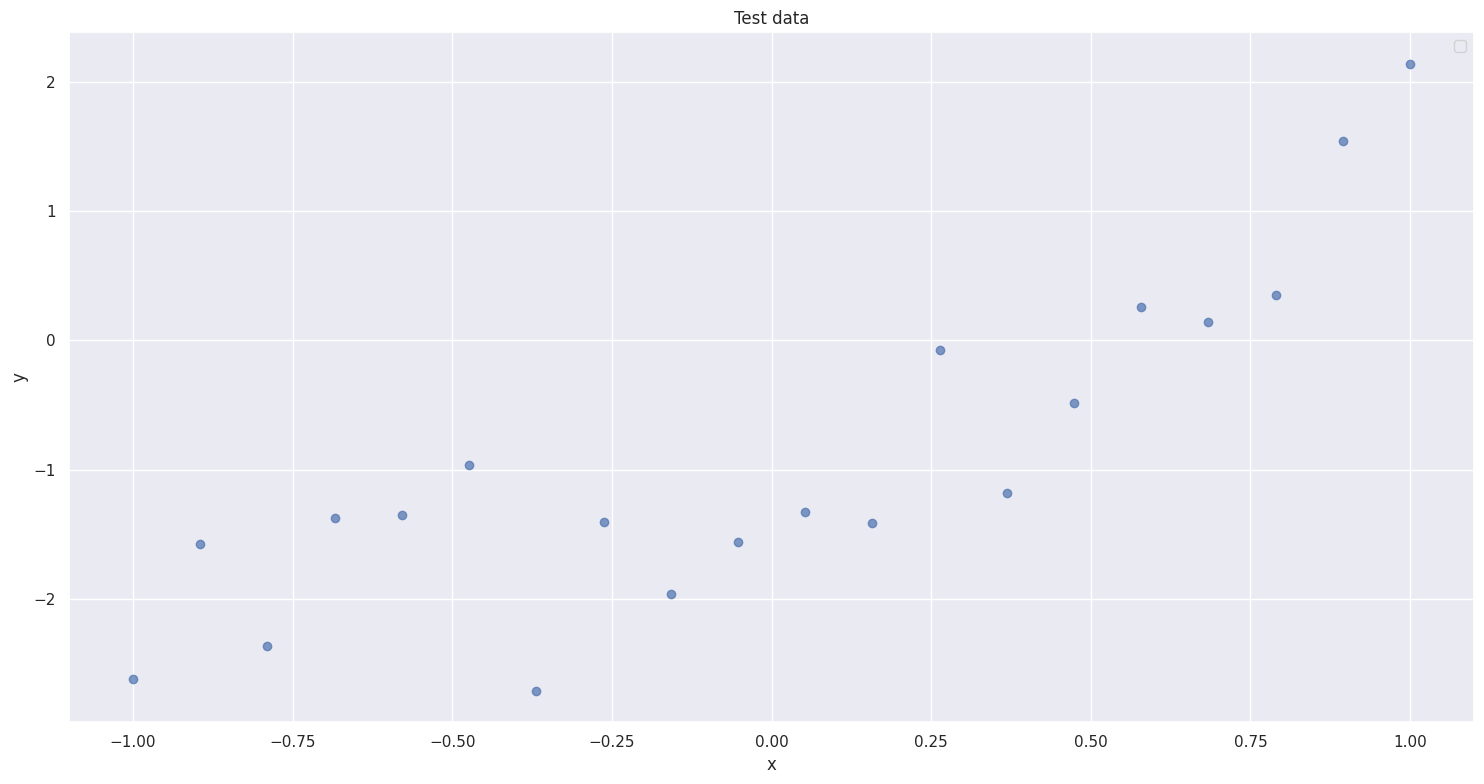

In [ ]:
plt.figure(figsize=(15, 8))
plt.scatter(x, y, alpha=0.7)

plt.title('Test data')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.tight_layout()

plt.show()

<ipython-input-8-5f0d87112b03>:3: RankWarning: Polyfit may be poorly conditioned
  coef_30 = np.polyfit(x, y, 30)


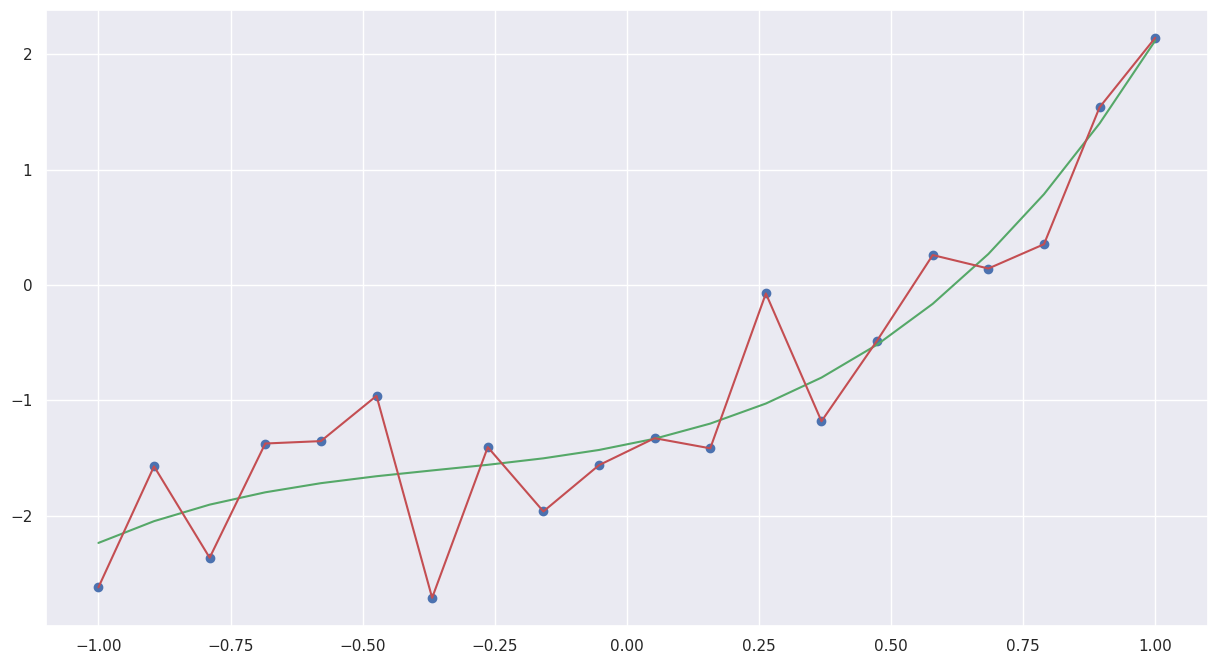

In [ ]:
# 使用 np.polyfit 查找所需次数的多项式依赖关系
coef_3 = np.polyfit(x, y, 3)
coef_30 = np.polyfit(x, y, 30)
preds_3 = np.polyval(coef_3, x)
preds_30 = np.polyval(coef_30, x)

# 让我们显示得到的结果
plt.figure(figsize=(15,8))
plt.scatter(x, y);
plt.plot(x, preds_3, c="g");
plt.plot(x, preds_30, c="r");

Кажется, что-то не так. Полином 30 степени, конечно, справился с приближением  предложенных ему конкретных точек, но кажется, что он выучил не настоящую зависимость, а скорее обусловленную какими-то случайными факторами.

Для того чтобы понять, всё ли он делает правильно, мы должны предложить ему какие-то новые примеры, на которых он не учился. Такие примеры называются **тестовой выборкой**.
Сгенерируем тестовую выборку из того же распределения и проверим, насколько хорош этот полином при тестировании.

似乎有些不对劲。当然，30 次多项式可以应对向它提出的具体点的近似值，但它似乎没有学到真正的依赖关系，而是学到了受一些随机因素影响的依赖关系。

为了了解他所做的一切是否正确，我们必须向他提供一些他尚未学到的新例子。这样的例子被称为**测试样本**。
让我们从相同的分布中生成一个测试样本，并检查这个多项式在测试中的表现如何。

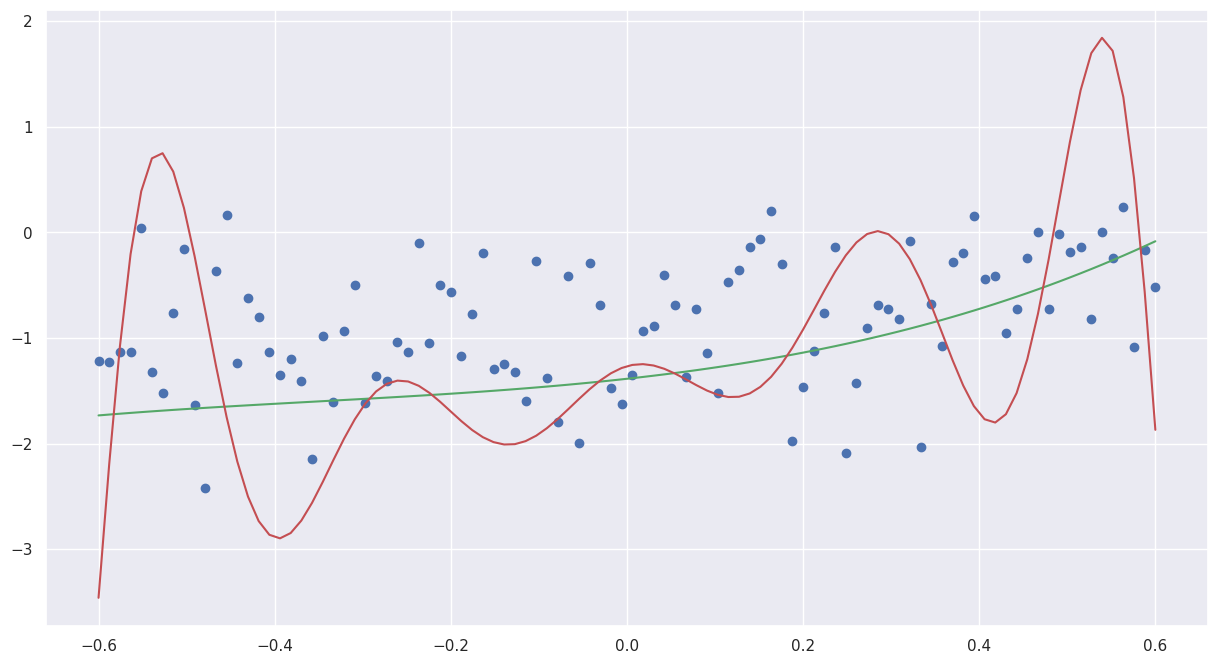

In [ ]:
x_test = np.linspace(-0.6, 0.6, 100)
y_test = np.polyval([2, 1, 0.3, -1], x_test) + np.random.randn(x_test.shape[0]) * 0.5

preds_test_3 = np.polyval(coef_3, x_test)
preds_test_30 = np.polyval(coef_30, x_test)

plt.figure(figsize=(15,8))
plt.scatter(x_test, y_test)
plt.plot(x_test, preds_test_3, c="g")
plt.plot(x_test, preds_test_30, c="r")

Очевидно, полином 3 степени проявляет себя существенно лучше. Это можно подтвердить, измерив метрики качества регрессии.

显然，三次多项式的表现要好得多。这可以通过测量回归质量指标来确认。

In [ ]:
from sklearn.metrics import mean_absolute_error as mse

mse_3_train = mse(y, preds_3)
mse_30_train = mse(y, preds_30)
mse_3_test = mse(y_test, preds_test_3)
mse_30_test = mse(y_test, preds_test_30)

In [ ]:
mse_3_train

0.36941090138029803

In [ ]:
mse_30_train

8.354371916485804e-11

In [ ]:
mse_3_test

0.5550770938313432

In [ ]:
mse_30_test

0.9459880708945329

Обратите внимание: ошибка полинома 30 степени на тренировочной выборке практически равна нулю. Это связано с тем, что в тренировочной выборке было всего 20 точек. Всегда можно подобрать такой полином 30 степени, чтобы он проходил через все точки произвольного набора из 20 штук. А вот на тестовой выборке его результат почти в 2 раза хуже результата на тестовой выборке.

Приведённый способ - один из основных способов отслеживания переобучения.

______________________________________________

注意，训练样本上的30次多项式的误差几乎为零。这是因为训练样本中只有 20 个点。总是可以选择一个 30 次的多项式，使得它穿过任意 20 个点集的所有点。但在测试样本上，他的成绩几乎比测试样本上的结果差2倍。

给定的方法是追踪过度拟合的主要方法之一。

______________________________________________

# Достоинства и недостатки


优点和缺点

## Достоинства
- Они легко интерпретируемы. В бизнесе это часто становится ключевым. Более сложные алгоритмы (о которых мы поговорим позже) напоминают «чёрный ящик» и не ясно, по какому именно принципу они принимают решения. Деревья решений могут легко визуализироваться: можно почти всегда ответить на вопрос почему на этом объекте получился данный прогноз.
- Годятся и для классификации, и для регрессии — в этом случае в листьях дерева будут числа, а не значение класса.
- Достаточно быстры.
- Не требуют серьезной предобработки данных: деревья не чувствительны к масштабу признаков и устойчивы к их мультиколлинеарности (наличие линейной зависимости между объясняющими переменными (факторами) регрессионной модели).
- Может работать как с числовыми, так и с категориальными признаками.
- Умеет работать с пропусками в данных, хоть и это довольно сложно поддерживается на кодовой основе


优点
- 它们很容易解释。在商业中，这往往成为关键。更复杂的算法（我们将在后面讨论）类似于“黑匣子”，并且不清楚它们究竟根据什么原理做出决策。决策树可以轻松地实现可视化：您几乎总是可以回答为什么针对给定对象获得给定预测的问题。
- 它们适用于分类和回归 - 在这种情况下，树叶将包含数字，而不是类值。
- 相当快。
- 不需要对数据进行严格的预处理：树对特征的规模不敏感，并且能够抵抗多重共线性（回归模型的解释变量（因素）之间存在线性关系）。
- 可以处理数字和分类特征。
- 可以处理数据缺口，尽管从代码角度支持这一点相当困难


## Недостатки
- Они сильно переобучаются, модель слишком сильно подгоняет параметры (разбиение веток) под обучающую выборку. На train она будет работать очень хорошо, а вот на новых данных - нет.  Необходимость отсекать ветви дерева (pruning) или устанавливать минимальное число элементов в листьях дерева или максимальную глубину дерева для борьбы с переобучением.
- Деревья очень чувствительны к шуму во входных данных, вся модель может кардинально измениться, если немного изменится обучающая выборка
- Нестабильность. Небольшие изменения в данных могут существенно изменять построенное дерево решений. С этой проблемой борются с помощью ансамблей деревьев решений (рассмотрим далее).
- Модель умеет только интерполировать, но не экстраполировать (это же верно и для леса и бустинга на деревьях). То есть дерево решений делает константный прогноз для объектов, находящихся в признаковом пространстве вне параллелепипеда, охватывающего все объекты обучающей выборки.
- Разделяющая граница, построенная деревом решений, имеет свои ограничения (состоит из гиперплоскостей, перпендикулярных какой-то из координатной оси). Часто можно получить очень сложное решение для очень простых задач.


缺陷
- 它们过度拟合，模型过多地调整参数（分支分裂）以适应训练样本。在火车上它能运行得很好，但在新数据上则不行。  需要修剪树枝（剪枝）或设置树叶元素的最小数量或树的最大深度，以防止过度拟合。
- 树对输入数据中的噪声非常敏感，训练集稍有变化，整个模型就会发生巨大变化
- 不稳定。数据中的微小变化可能会显著改变最终的决策树。这个问题可以通过使用决策树集合来解决（如下所述）。
- 模型只能进行内插，但不能进行外推（森林和树木增强也是如此）。也就是说，决策树对位于平行六面体之外的特征空间中的物体做出恒定的预测，该预测覆盖训练样本中的所有物体。
- 决策树构建的划分边界有其自身的局限性（由垂直于某些坐标轴的超平面组成）。通常你可以得到一个非常简单的问题的一个非常复杂的解决方案。

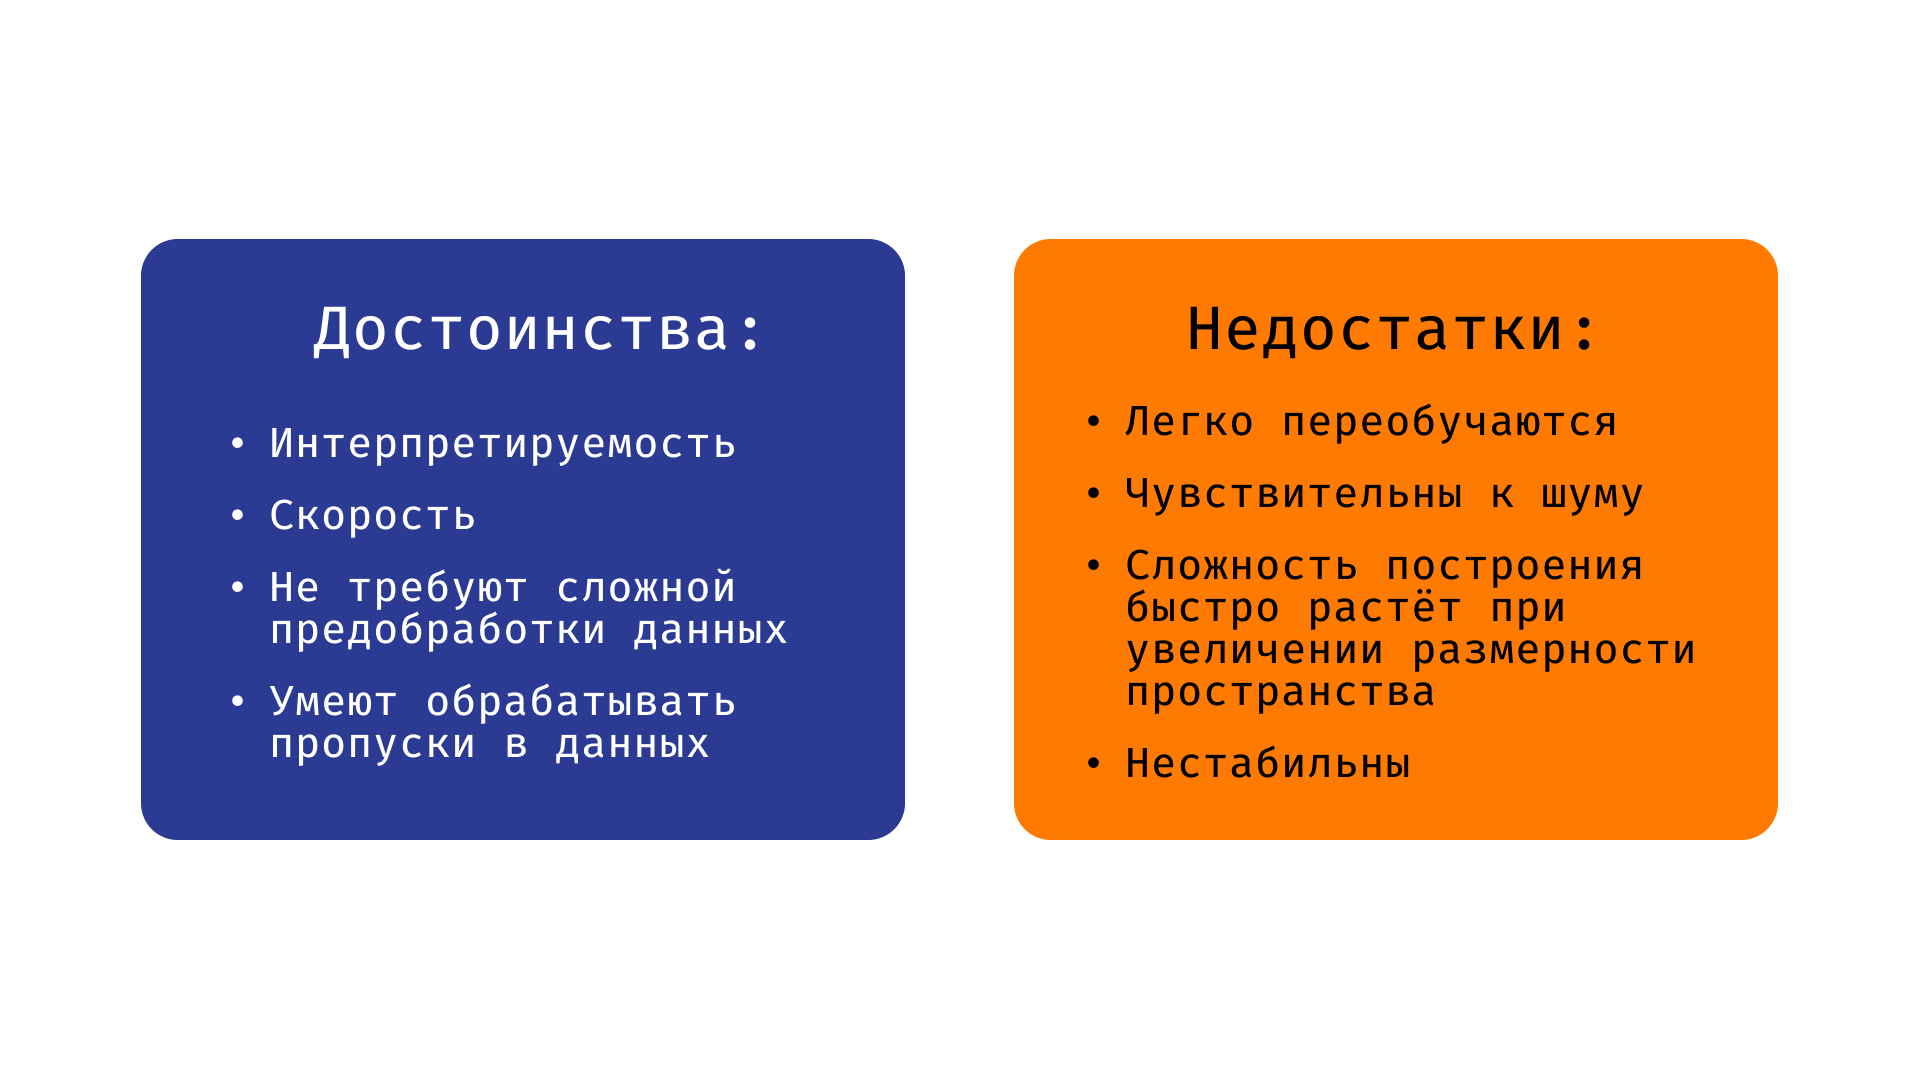

# Примеры

## Синтетический датасет

На примере этого датасета мы посмотрим, как выглядят области принятия решений в задачах классификации при решении этих задач решающими деревьями.

合成数据集

以该数据集为例，我们将看到在使用决策树解决分类问题时，决策域在分类问题中是什么样的。

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme()

# 将点添加到第一类的平面
np.seed = 10
train_data = np.random.normal(size=(50, 2))
train_data = np.r_[train_data, np.random.normal(size=(50, 2), loc=0.5, scale=2)]
train_labels = np.zeros(100)

# 添加第二个类别的点
train_data = np.r_[train_data, np.random.normal(size=(100, 2), loc=4, scale=2)]
train_labels = np.r_[train_labels, np.ones(100)]

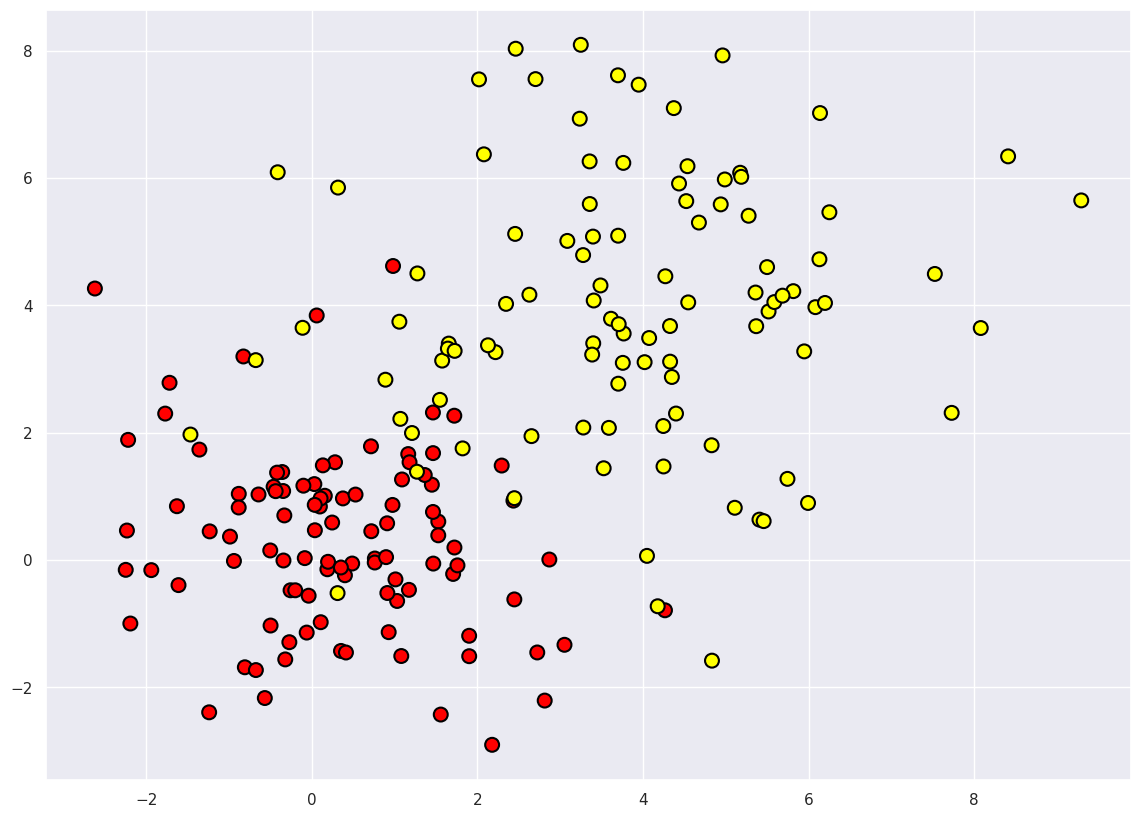

In [ ]:
plt.rcParams["figure.figsize"] = (14, 10)
plt.scatter(
    train_data[:, 0],
    train_data[:, 1],
    c=train_labels,
    s=100,
    cmap="autumn",
    edgecolors="black",
    linewidth=1.5,
)


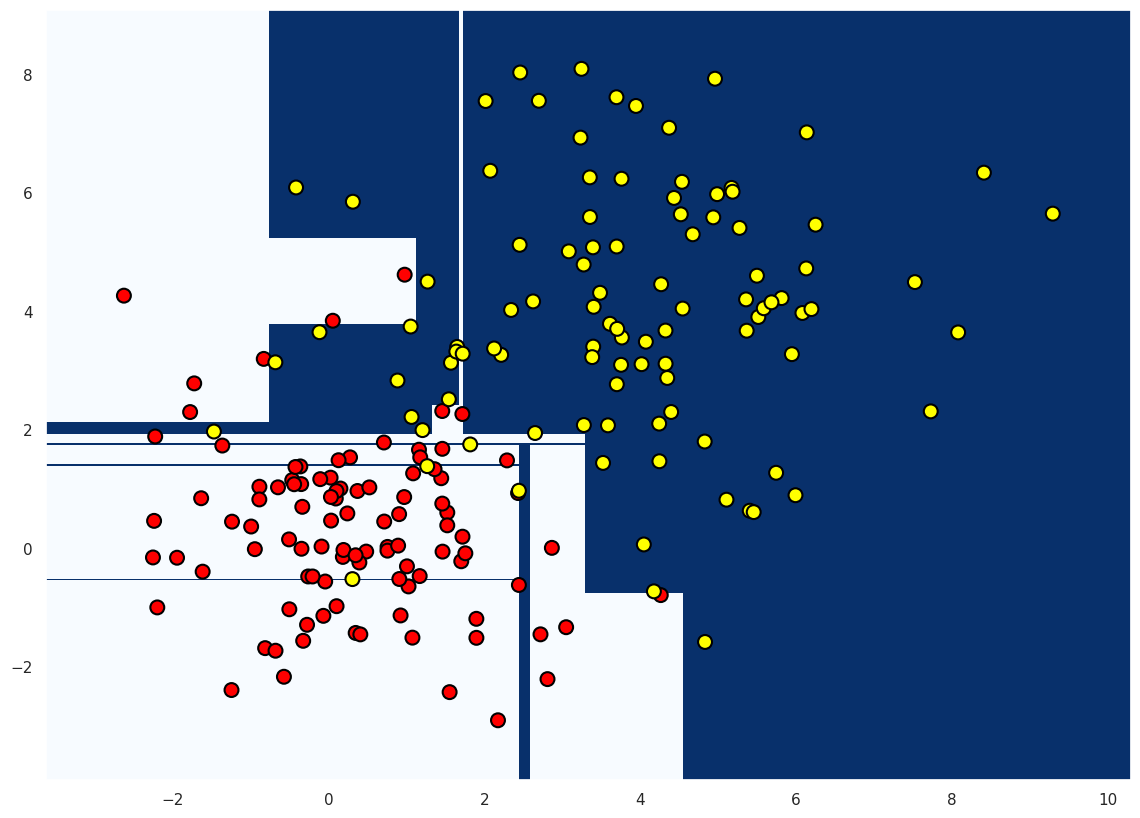

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# 让我们编写一个辅助函数，它将返回一个网格以供进一步渲染
def get_grid(data):
    x_min, x_max = data[:, 0].min() - 1, data[:, 0].max() + 1
    y_min, y_max = data[:, 1].min() - 1, data[:, 1].max() + 1
    return np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))



clf_tree = DecisionTreeClassifier(criterion="gini", max_depth=30, random_state=17)

# 树的训练
clf_tree.fit(train_data, train_labels)

# 分割面
xx, yy = get_grid(train_data)
predicted = clf_tree.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.pcolormesh(xx, yy, predicted, cmap="Blues")
plt.scatter(
    train_data[:, 0],
    train_data[:, 1],
    c=train_labels,
    s=100,
    cmap="autumn",
    edgecolors="black",
    linewidth=1.5,
);

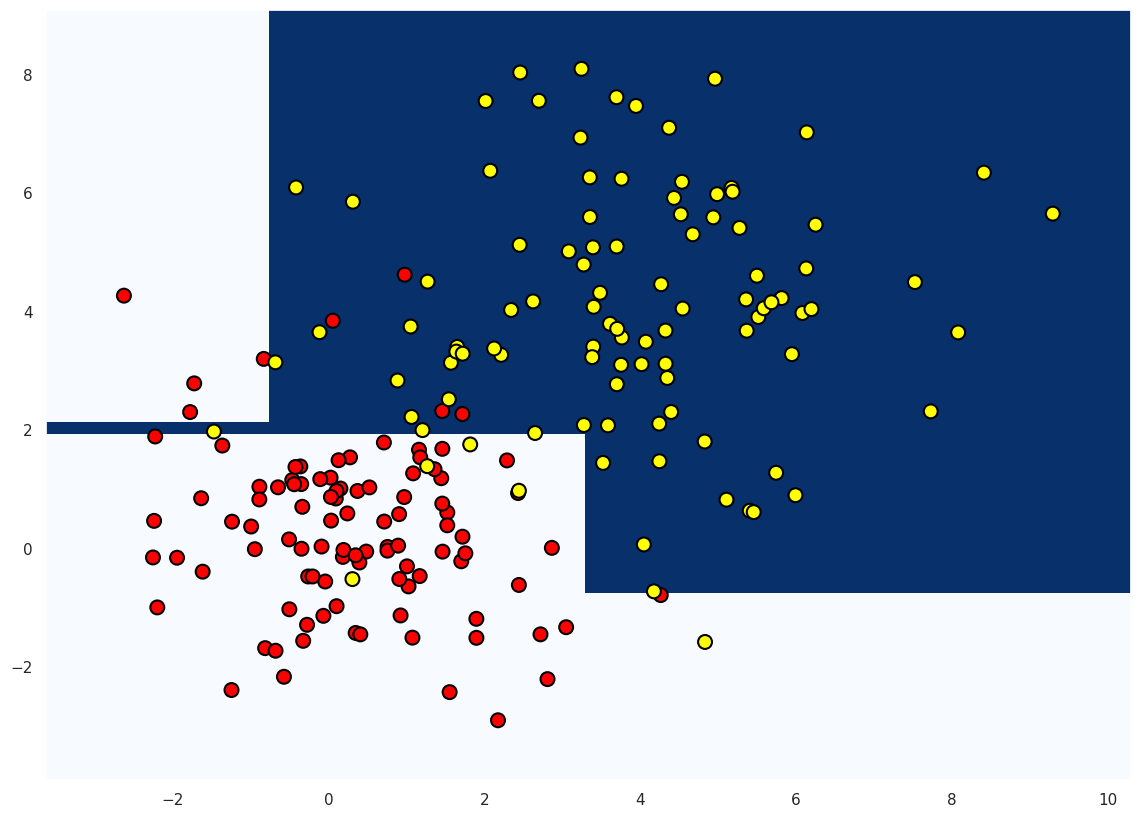

In [ ]:
clf_tree = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=17)

# 树的训练
clf_tree.fit(train_data, train_labels)

# 分割面
xx, yy = get_grid(train_data)
predicted = clf_tree.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.pcolormesh(xx, yy, predicted, cmap="Blues")
plt.scatter(
    train_data[:, 0],
    train_data[:, 1],
    c=train_labels,
    s=100,
    cmap="autumn",
    edgecolors="black",
    linewidth=1.5,
);

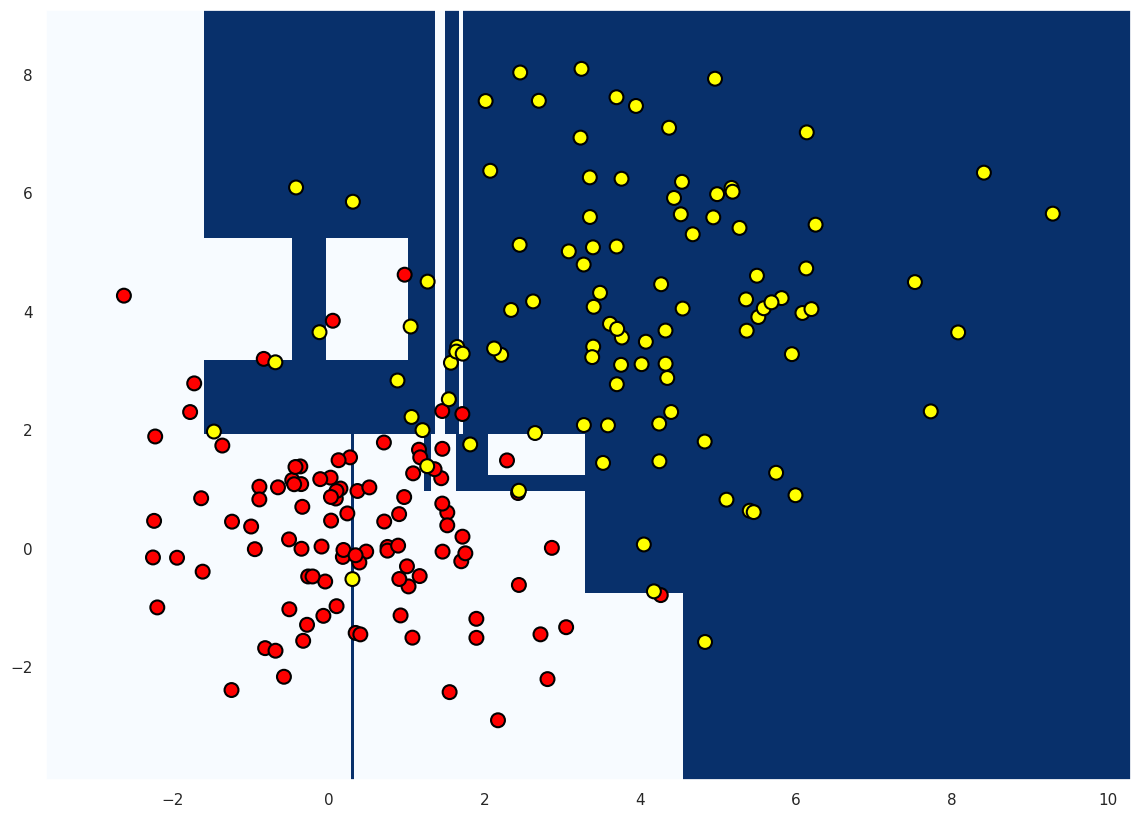

In [ ]:
clf_tree = DecisionTreeClassifier(criterion="entropy", max_depth=30, random_state=17)

# 树的训练
clf_tree.fit(train_data, train_labels)

# 分割面
xx, yy = get_grid(train_data)
predicted = clf_tree.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.pcolormesh(xx, yy, predicted, cmap="Blues")
plt.scatter(
    train_data[:, 0],
    train_data[:, 1],
    c=train_labels,
    s=100,
    cmap="autumn",
    edgecolors="black",
    linewidth=1.5,
);

## IRIS Dataset
Теперь обратимся к уже полюбившемуся нам датасету ирисов Фишера. Посмотрим на области принятия решений, спроецированные на двумерные подпространства признаков.

IRIS 数据集
现在让我们转向我们已经喜爱的 Fisher 鸢尾花数据集。让我们看一下投影到二维特征子空间的决策域。

In [ ]:
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn import linear_model
from sklearn import metrics

In [ ]:
iris = datasets.load_iris()
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

Целевая переменная - сорт цветка-ириса:
- 0 - Setosa
- 1 - Versicolor
- 2 - Virginica

**Задача.** Найти зависимости между размерами (длина/ширина) лепестков и сортами ирисов.

目标变量是鸢尾花的品种：
- 0 - 塞托萨
- 1 - 杂色
- 2 - 处女

**问题。**找到花瓣的大小（长度/宽度）和鸢尾花品种之间的关系。

In [ ]:
df = pd.DataFrame(iris.data)
df.columns = iris.feature_names
df["target"] = iris.target
df["name"] = df.target.apply(lambda x: iris.target_names[x])
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica


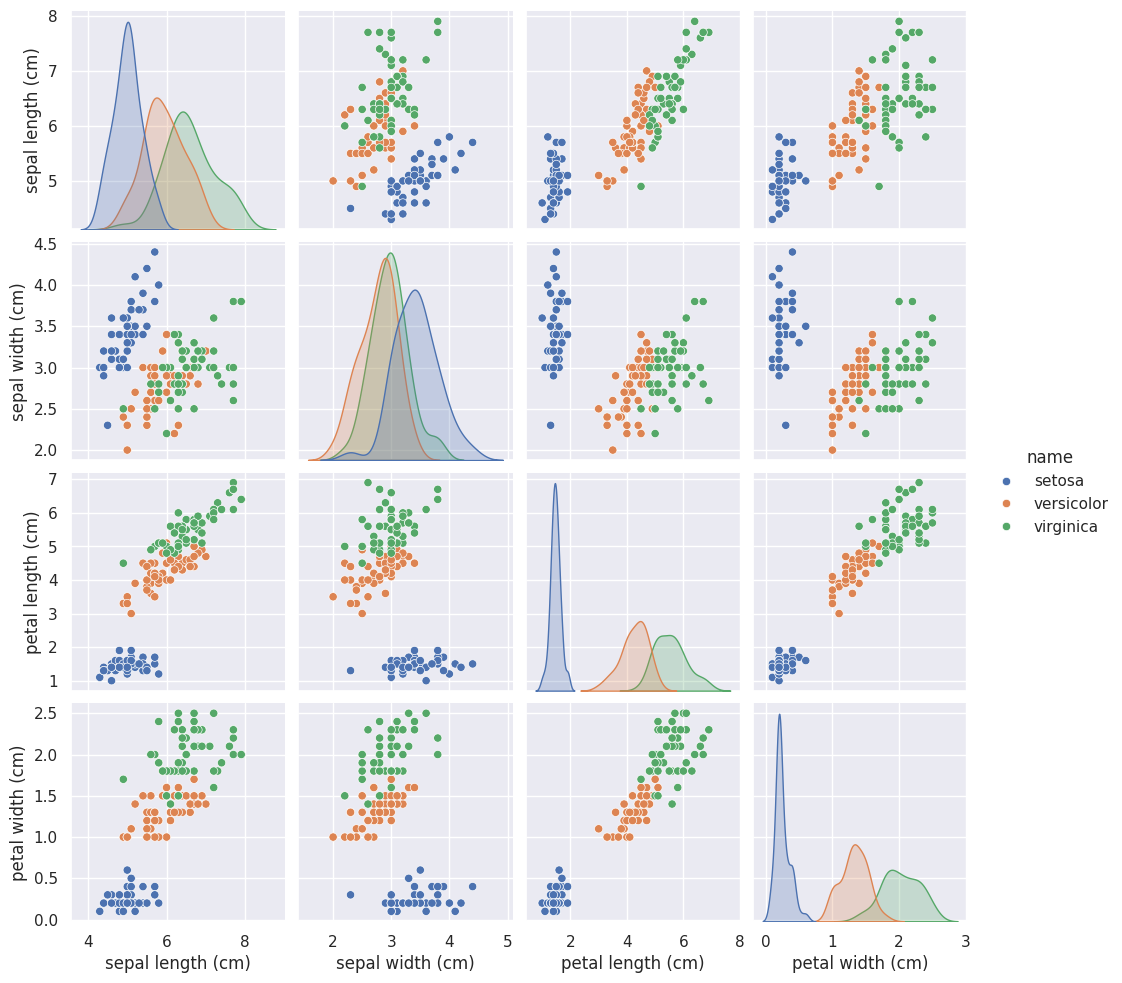

In [ ]:
sns.pairplot(df[['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)', 'name']], hue = 'name')

<ipython-input-26-07613f0f88c1>:37: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(
<ipython-input-26-07613f0f88c1>:37: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(
<ipython-input-26-07613f0f88c1>:37: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


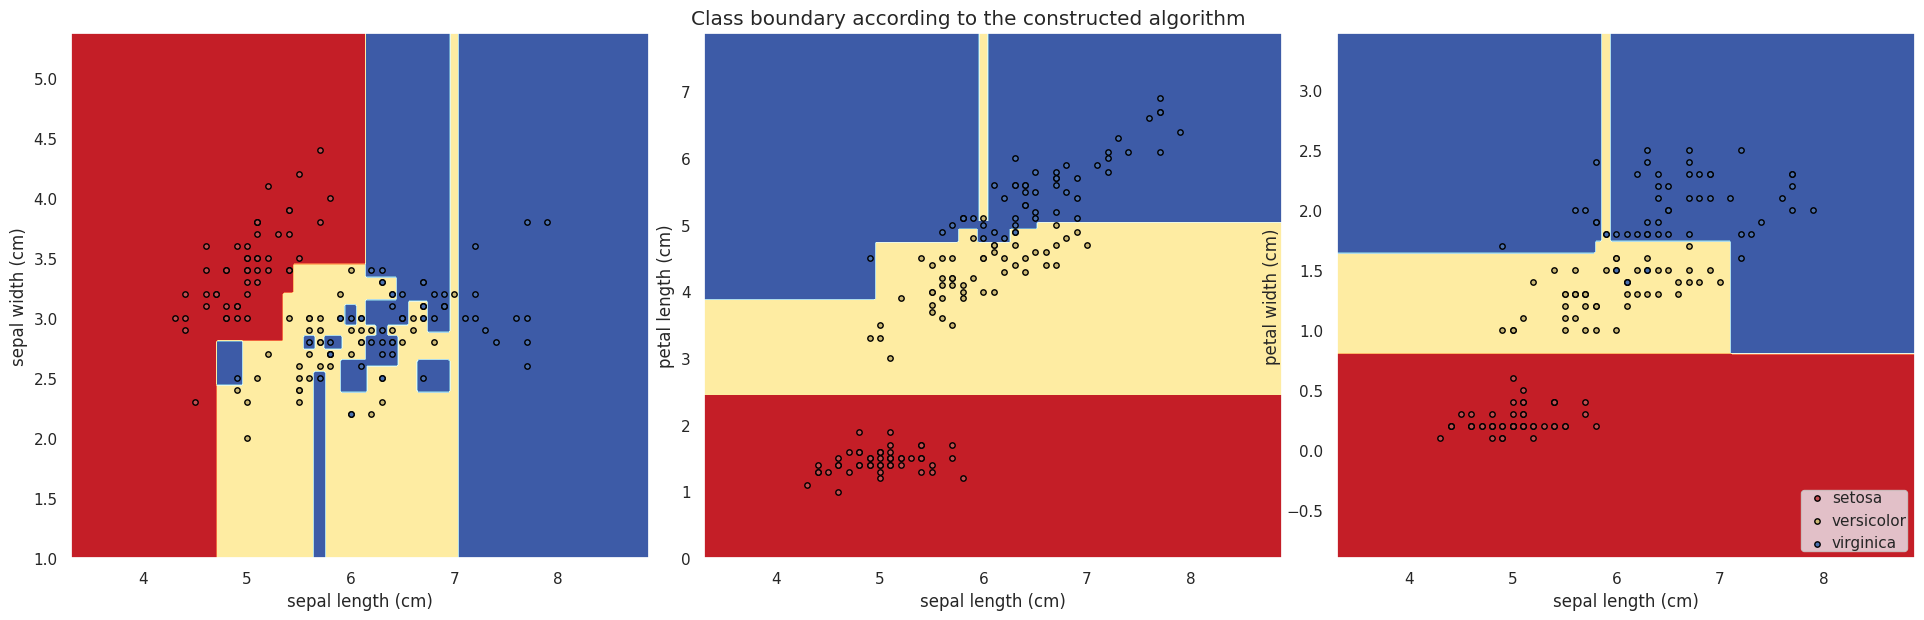

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

# 设置参数
n_classes = 3
plot_colors = "ryb"
plot_step = 0.02
plt.figure(figsize=(20, 12))
for pairidx, pair in enumerate([[0, 1], [0, 2], [0, 3]]):
    # 选择当前的特征对
    X = iris.data[:, pair]
    y = iris.target

    # 训练模型
    clf = DecisionTreeClassifier(max_depth=40).fit(X, y)

    # 让我们画出类别边界
    plt.subplot(2, 3, pairidx + 1)
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, plot_step), np.arange(y_min, y_max, plot_step)
    )
    plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cs = plt.contourf(xx, yy, Z, cmap=plt.cm.RdYlBu)

    plt.xlabel(iris.feature_names[pair[0]])
    plt.ylabel(iris.feature_names[pair[1]])

    # 预览
    for i, color in zip(range(n_classes), plot_colors):
        idx = np.where(y == i)
        plt.scatter(
            X[idx, 0],
            X[idx, 1],
            c=color,
            label=iris.target_names[i],
            cmap=plt.cm.RdYlBu,
            edgecolor="black",
            s=15,
        )

plt.suptitle("Class boundary according to the constructed algorithm")
plt.legend(loc="lower right", borderpad=0, handletextpad=0)

## Короткий пример решения задачи регрессии

Напоследок приведем пример решения задачи регрессии при помощи решающих деревьев

Попробуем применить решающие деревья для предсказания стоимости квартиры в Калифорнии (популярный датасет california housing).

Подберём оптимальное ограничение на глубину решающего дерева (параметр max_depth). Именно этот параметр используется чтобы избежать переобучения модели.

解决回归问题的一个简短例子

最后，我们将给出一个使用决策树解决回归问题的例子。

让我们尝试应用决策树来预测加州公寓的价格（流行的加州住房数据集）。

让我们选择决策树深度的最佳限制（参数max_depth）。该参数用于避免模型过度拟合。

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
import tqdm
from tqdm.auto import tqdm

X, y = fetch_california_housing(return_X_y=True)
X_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=True)

scores = []
train_scores = []
for max_d in tqdm(range(2, 100)):
    reg = DecisionTreeRegressor(max_depth=max_d)
    reg.fit(X_train, y_train)
    test_score = reg.score(x_test, y_test)
    train_scores.append(reg.score(X_train, y_train))
    scores.append(test_score)

  0%|          | 0/98 [00:00<?, ?it/s]

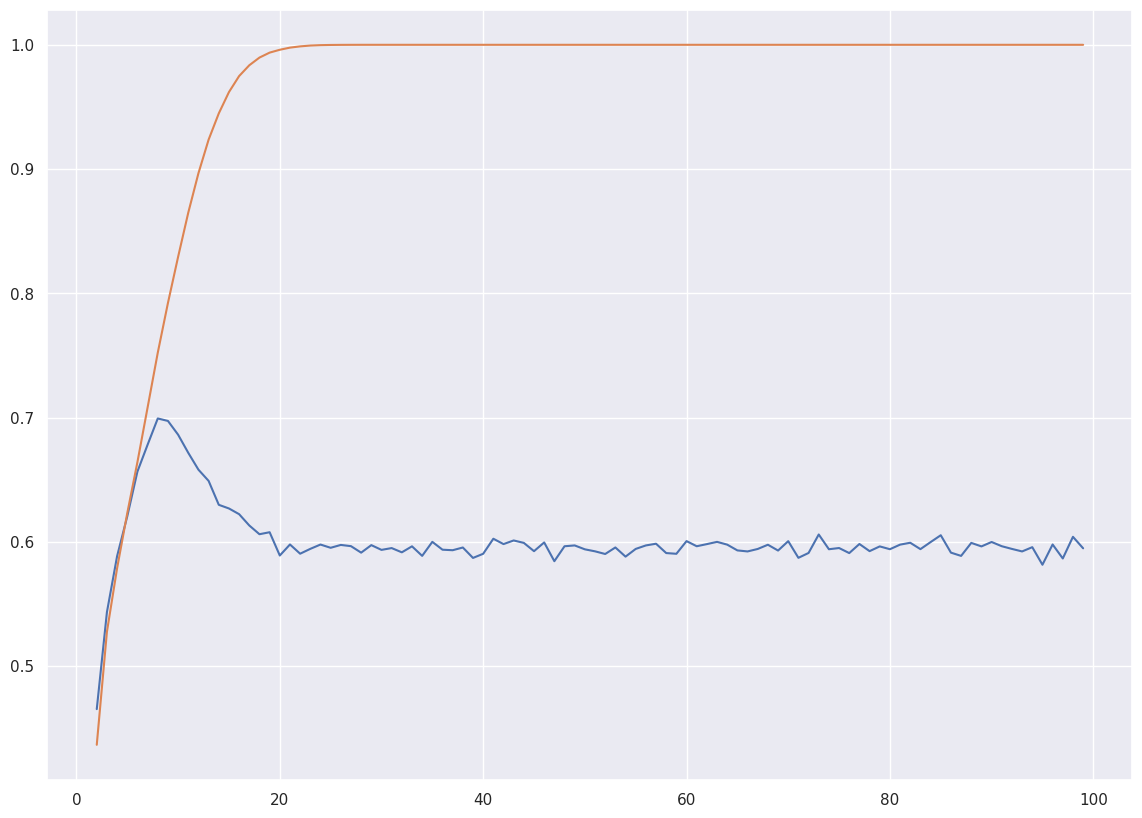

In [ ]:
from matplotlib import pyplot as plt

plt.plot(list(range(2, 100)), scores)
plt.plot(list(range(2, 100)), train_scores)

In [ ]:
max(scores)

0.699358110826223

In [ ]:
import numpy as np
np.argmax(scores)

np.int64(6)

Соответственно наилучший показатель достигнут при ограничении глубины дерева, равной 2+ найденное значение

因此，通过将树深度限制为 2+ 找到的值来实现最佳指标